## Diagnostyka danych

In [2]:
# ============================================
#                   Importy 
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# ============================================
#               Wczytanie danych 
# ============================================

df = pd.read_csv("World Energy Consumption.csv")

# ============================================
#               Diagnostyka danych
# ============================================

df.head()

#df.describe()  # Statystyki opisowe dla kolumn numerycznych (min, max, średnia, kwartyle)


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
df.info()
print("Duplikaty:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.7+ MB
Duplikaty: 0


In [5]:
# Typy danych
df.dtypes




country                    object
year                        int64
iso_code                   object
population                float64
gdp                       float64
                           ...   
wind_elec_per_capita      float64
wind_electricity          float64
wind_energy_per_capita    float64
wind_share_elec           float64
wind_share_energy         float64
Length: 129, dtype: object

In [6]:
# ============================================
#         Sprawdzenie braków danych
# ============================================

# Zliczenia brakujących wartości (NaN/null) w każdej kolumnie i wyświetlenia ich w kolejności od tej, która ma tych braków najwięcej.
df.isna().sum().sort_values(ascending=False) 



biofuel_cons_change_pct    20265
solar_cons_change_pct      19888
biofuel_cons_per_capita    19710
wind_cons_change_pct       19599
nuclear_cons_change_pct    19545
                           ...  
oil_prod_change_twh         4864
oil_production              4607
population                  3889
year                           0
country                        0
Length: 129, dtype: int64

In [7]:
# Łączna liczba braków danych w danym roku.

missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())
missing_by_year

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_8682/415707937.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df.groupby('year').apply(lambda x: x.isna().sum().sum())


year
1900    14224
1901    13871
1902    13869
1903    13868
1904    13866
        ...  
2018    17382
2019    17700
2020    17586
2021    17465
2022     6658
Length: 123, dtype: int64

In [8]:
# Sprawdzenie braków dla krajów

df.groupby('country').apply(lambda x: x.isna().mean()).sort_values('primary_energy_consumption')

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_8682/2044724284.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('country').apply(lambda x: x.isna().mean()).sort_values('primary_energy_consumption')


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
country,,,,,,,,,,,,,,,,,,,,,
Luxembourg,0.0,0.0,0.0,0.0,0.068966,0.741379,0.448276,0.431034,0.431034,0.431034,...,0.431034,0.431034,0.568966,0.448276,0.431034,0.431034,0.431034,0.431034,0.431034,0.431034
Guinea-Bissau,0.0,0.0,0.0,0.0,0.071429,1.000000,1.000000,1.000000,1.000000,0.476190,...,0.476190,1.000000,1.000000,1.000000,1.000000,0.476190,0.476190,1.000000,0.476190,1.000000
Guyana,0.0,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,0.476190,...,0.476190,1.000000,1.000000,1.000000,1.000000,0.476190,0.476190,1.000000,0.476190,1.000000
Haiti,0.0,0.0,0.0,0.0,0.071429,1.000000,1.000000,1.000000,1.000000,0.476190,...,0.476190,1.000000,1.000000,1.000000,1.000000,0.476190,0.476190,1.000000,0.476190,1.000000
Hawaiian Trade Zone (EIA),0.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G20 (Ember),0.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
Persian Gulf (Shift),0.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Europe (Shift),0.0,0.0,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Wizualizacja braków

Text(0.5, 1.0, 'Braki współistniejące')

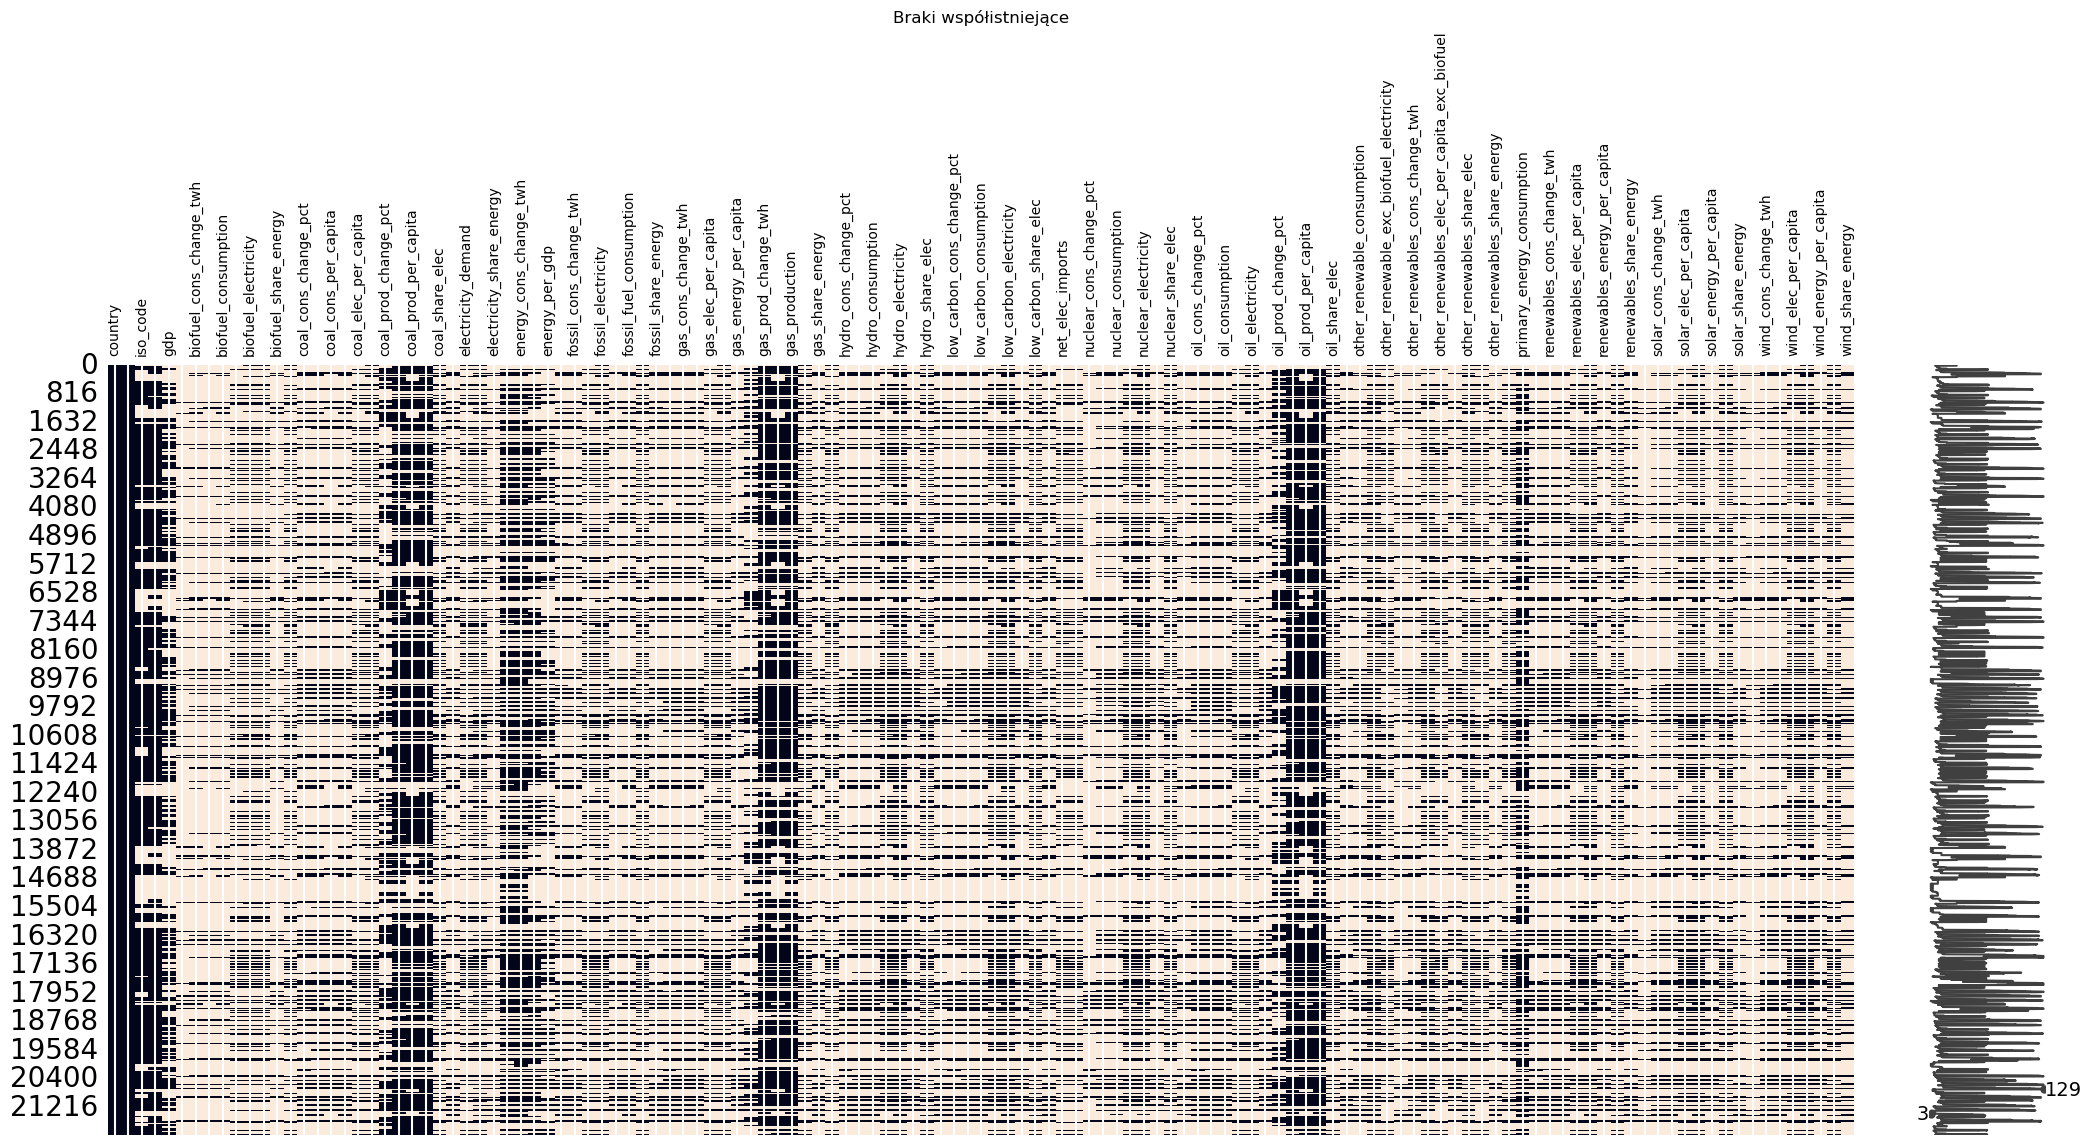

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

"""
matrix – czy braki występują w blokach (np. starsze lata), 
heatmap – czy braki współwystępują (np. brak solar → brak wind),
Heatmapa braków danych przedstawia zmienne na osi X oraz obserwacje (kraj–rok) na osi Y.
Jasne pola oznaczają wartości brakujące, a ciemne pola wartości dostępne. 
"""
msno.matrix(df);
plt.title('Braki')

sns.heatmap(df.isna(), cbar=False)  
plt.title('Braki współistniejące')



<Axes: >

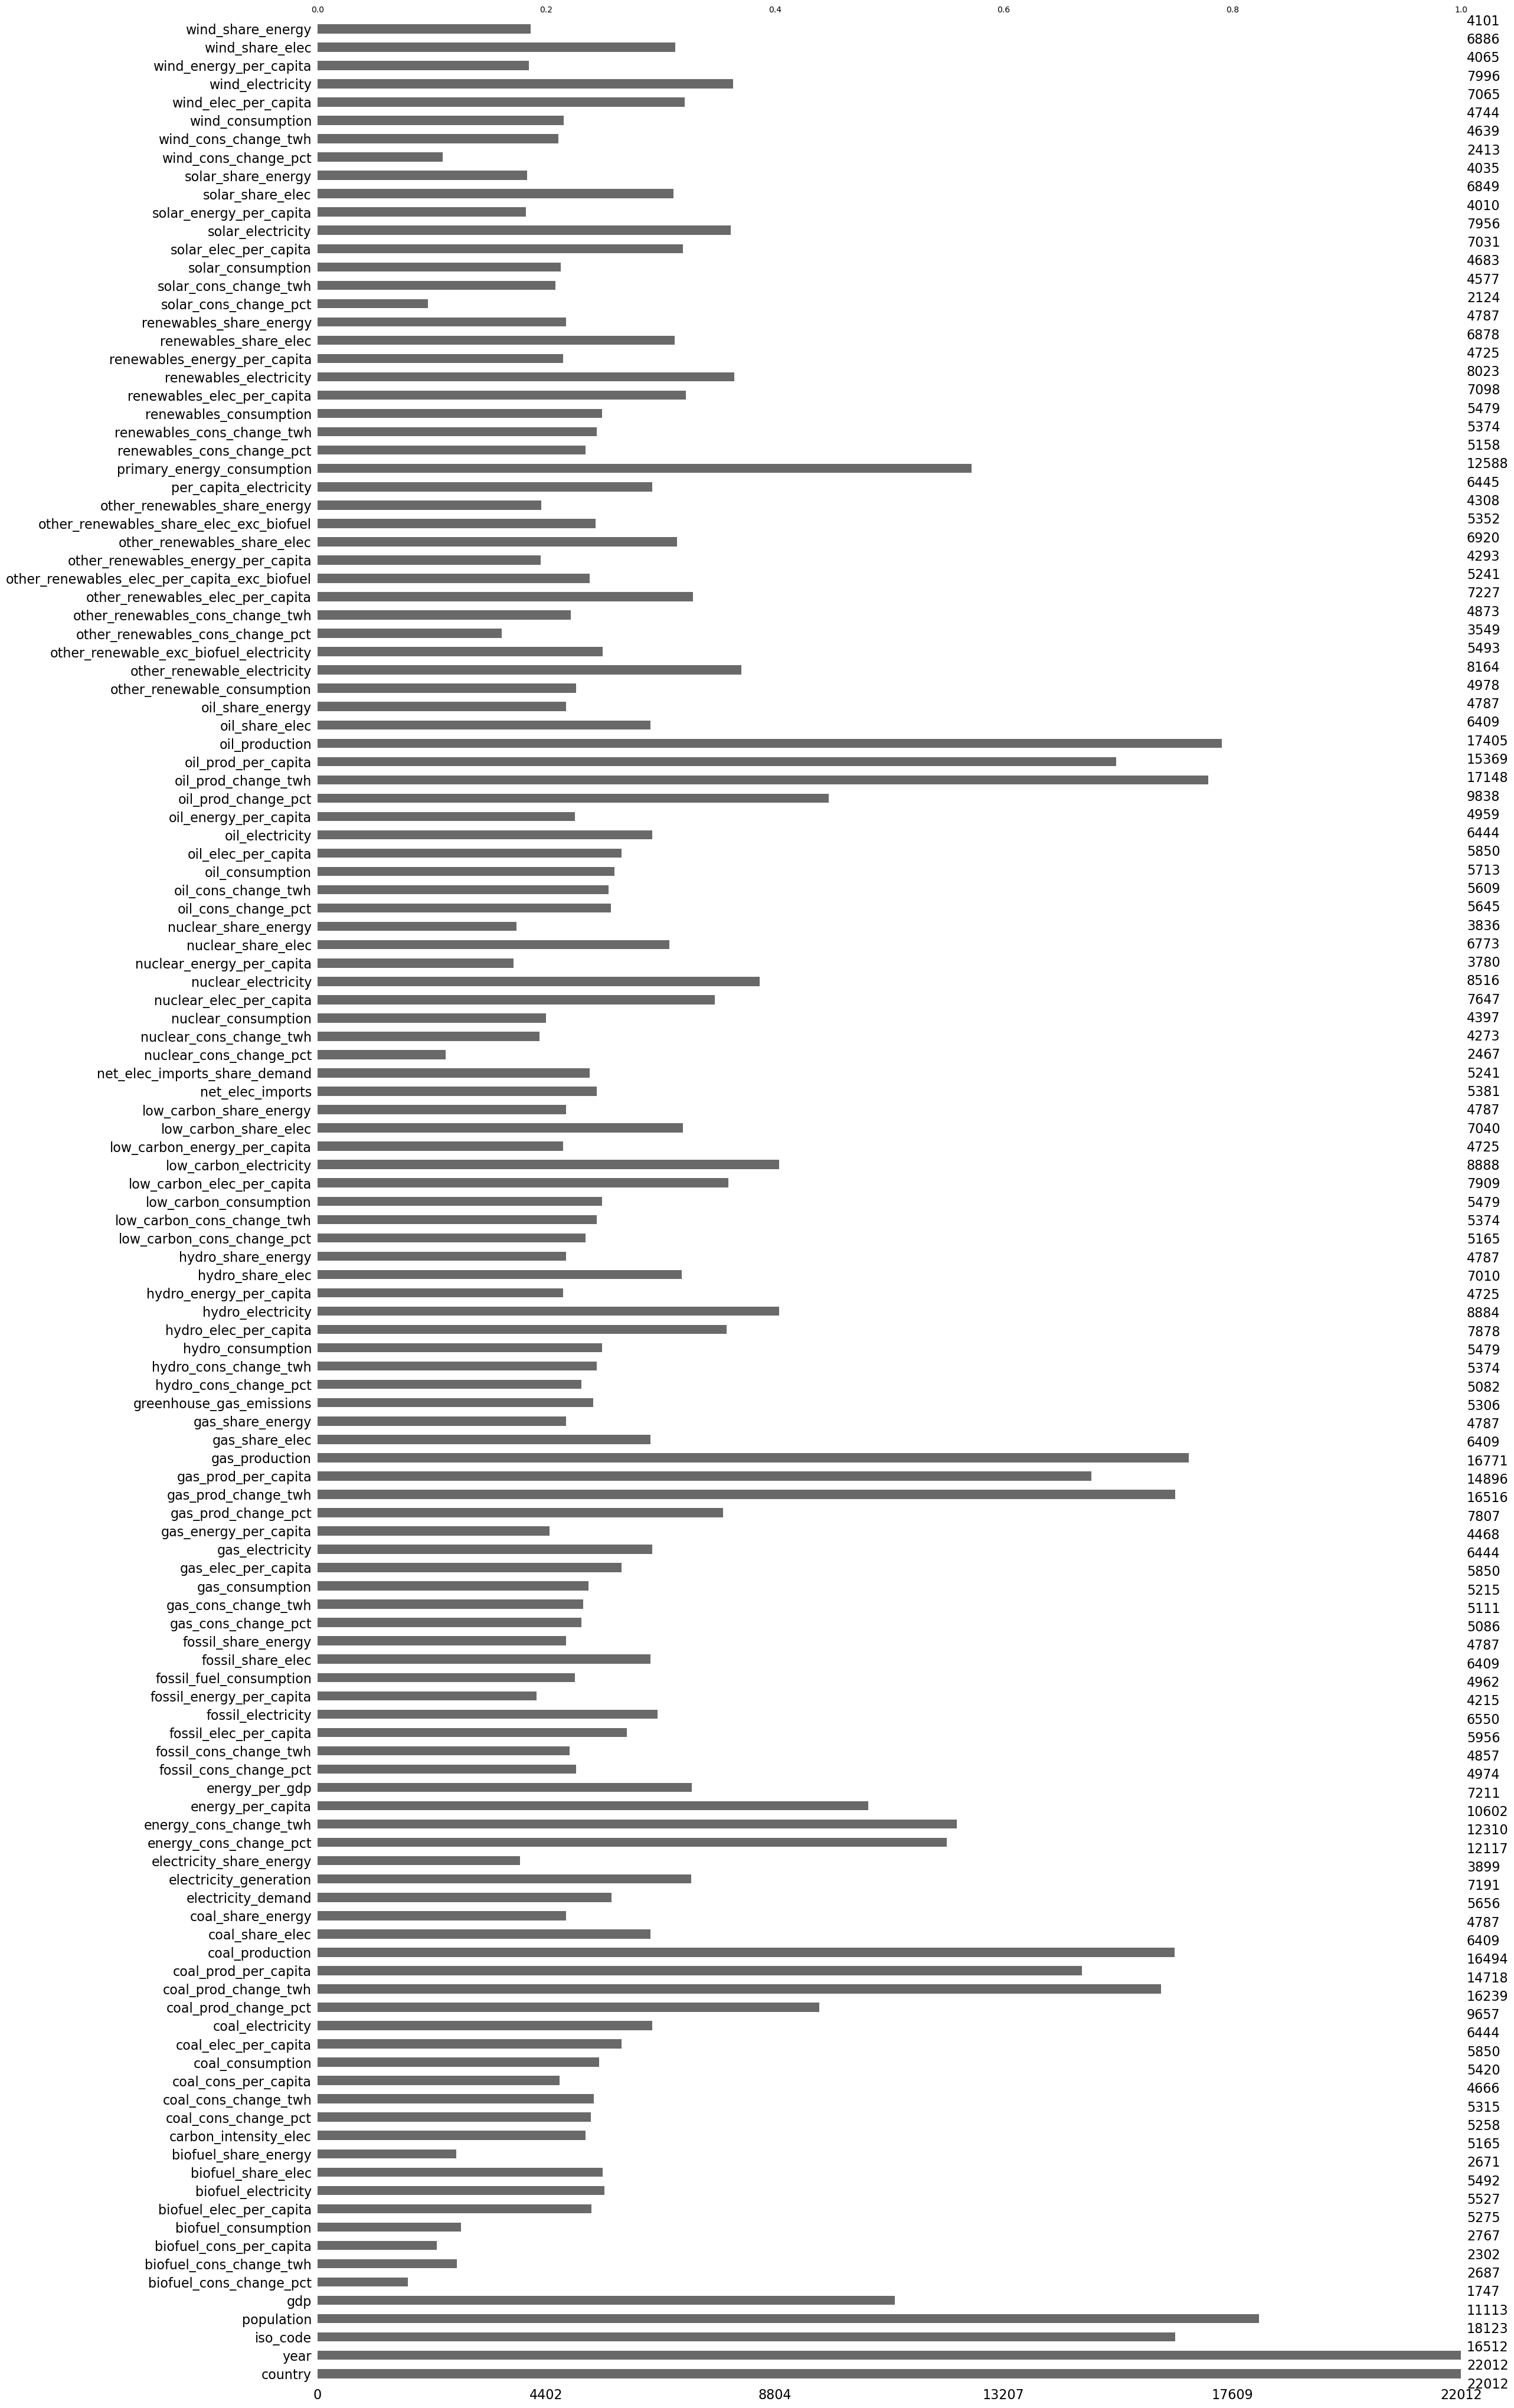

In [10]:
# bar – ile braków ma każda kolumna.
msno.bar(df)

/var/folders/c9/ygg1ptk506n7_w3bl2_7q5840000gn/T/ipykernel_8682/1441697171.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year_var = df.groupby('year').apply(lambda x: x.isna().mean())


Text(0.5, 1.0, 'Procent braków danych dla każdej zmiennej w czasie')

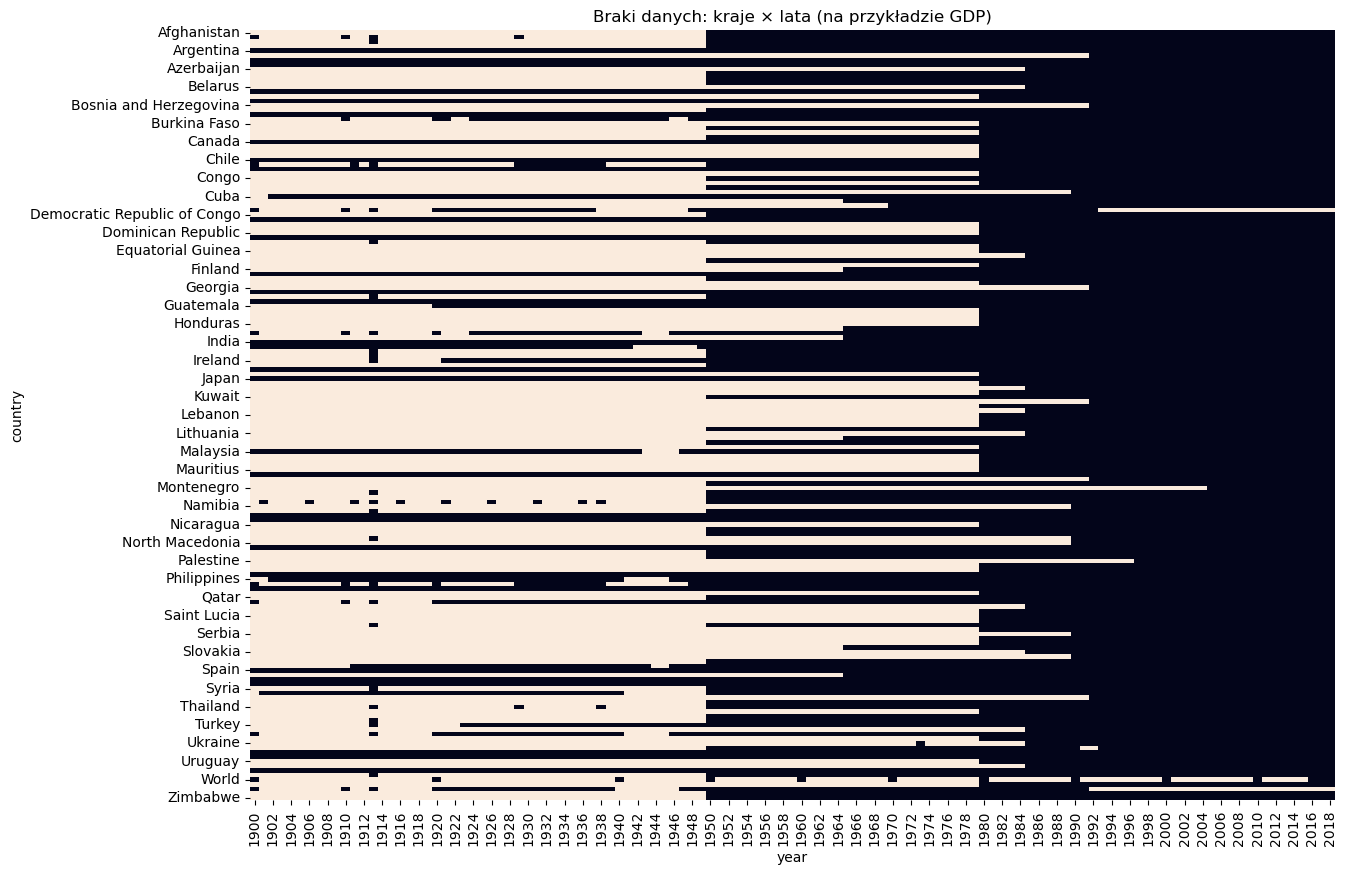

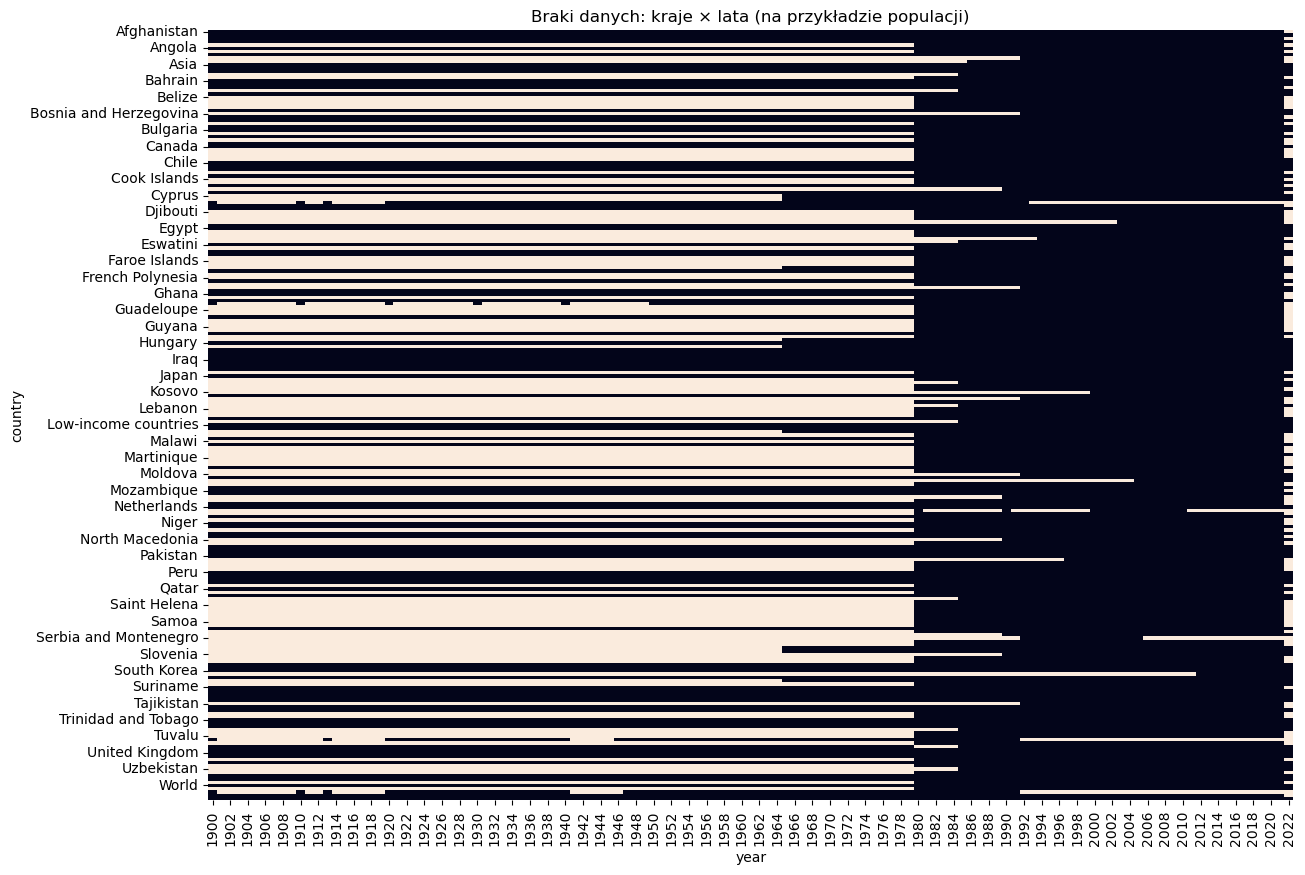

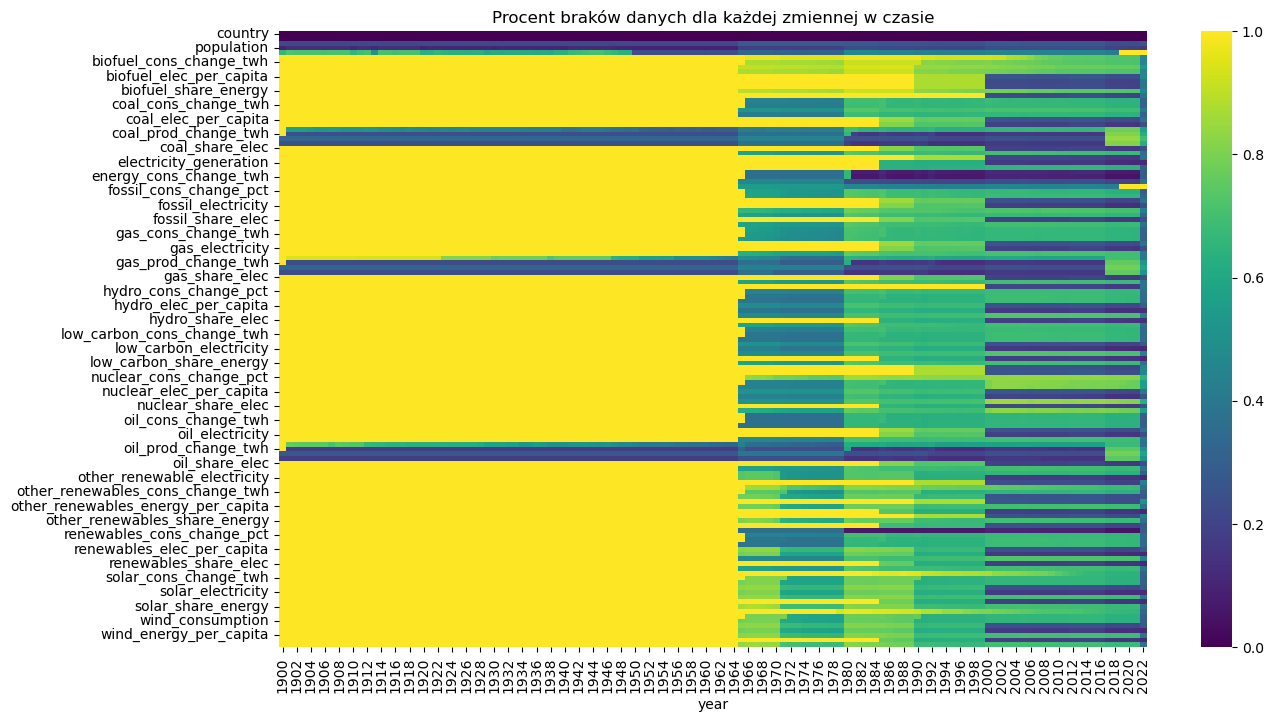

In [11]:
plt.figure(figsize=(14,10))
sns.heatmap(df.pivot_table(index='country', columns='year', values='gdp').isna(), 
            cbar=False)
plt.title('Braki danych: kraje × lata (na przykładzie GDP)')



plt.figure(figsize=(14,10))
sns.heatmap(df.pivot_table(index='country', columns='year', values='population').isna(), 
            cbar=False)
plt.title('Braki danych: kraje × lata (na przykładzie populacji)')



missing_by_year_var = df.groupby('year').apply(lambda x: x.isna().mean())
plt.figure(figsize=(14,8))
sns.heatmap(missing_by_year_var.T, cmap='viridis')
plt.title('Procent braków danych dla każdej zmiennej w czasie')

## Czyszczenie danych
* usunięcie regionów - nieprzydatne wiersze,
* usunięcie zmiennych o zbyt dużej liczbie braków (przyjete powyżej 60%),
* zmiejszenie zakresu lat (od 2000 roku).

W ramach czyszczenia danych usunięto wiersze odpowiadające regionom agregowanym (np. „World”, „Europe”, „OECD”), ponieważ nie reprezentują pojedynczych krajów i mają odmienne zakresy danych. Następnie usunięto zmienne zawierające ponad 60% braków, gdyż nie nadają się do rzetelnej analizy. Ograniczono również zakres lat do okresu od 2000 roku, ponieważ starsze dane charakteryzują się dużą liczbą braków oraz mniejszą spójnością. Dzięki tym krokom uzyskano bardziej kompletny, porównywalny i wiarygodny zbiór danych do dalszej analizy eksploracyjnej.

In [ ]:
# ============================================
#         Usuwanie zbędnych danych
# ============================================


# Lista regionów do usunięcia

regions = ['World', 'Africa', 'Asia', 'Europe', 'European Union', 'North America',
           'South America', 'Oceania', 'High-income countries', 'Low-income countries',
           'Upper-middle-income countries', 'Lower-middle-income countries', 'OECD']

df = df[~df['country'].isin(regions)]

Usunięto wiersze odpowiadające regionom agregowanym, ponieważ nie reprezentują pojedynczych krajów i mają odmienne zakresy danych. Pozostawiono wyłącznie dane krajowe, co zwiększa spójność analizy.

In [4]:
# Usunięcie zmiennych z >60% braków
threshold = 0.6
df = df.loc[:, df.isna().mean() < threshold]
df

,country,year,iso_code,population,gdp,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,energy_cons_change_pct,...,gas_prod_change_twh,gas_prod_per_capita,gas_production,hydro_electricity,low_carbon_electricity,oil_prod_change_pct,oil_prod_change_twh,oil_prod_per_capita,oil_production,primary_energy_consumption
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,50.37,72.90,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,54.26,76.68,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,53.32,75.99,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,53.28,75.71,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,52.88,77.02,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22007,Zimbabwe,2018,ZWE,15052191.0,2.271535e+10,14.336,3.148,1667.861,25.105,14.479,...,NaN,NaN,NaN,5.05,5.46,NaN,NaN,NaN,NaN,51.809
22008,Zimbabwe,2019,ZWE,15354606.0,NaN,-21.529,-5.405,1283.004,19.700,-10.982,...,NaN,NaN,NaN,4.17,4.58,NaN,NaN,NaN,NaN,46.120
22009,Zimbabwe,2020,ZWE,15669663.0,NaN,3.004,0.592,1294.978,20.292,-8.940,...,NaN,NaN,NaN,3.81,4.19,NaN,NaN,NaN,NaN,41.997
22010,Zimbabwe,2021,ZWE,15993525.0,NaN,19.708,3.999,1518.799,24.291,0.354,...,NaN,NaN,NaN,4.00,4.42,NaN,NaN,NaN,NaN,42.145


Usunięto zmienne, które miały ponad 60% braków. Pozwoliło to zachować tylko te cechy, które są wystarczająco kompletne, aby przeprowadzić rzetelną analizę.

# Imputacja braków

In [14]:
# wybór kolumn numerycznych
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# interpolacja po krajach z zachowaniem indeksu
df[num_cols] = df.groupby('country')[num_cols].transform(lambda x: x.interpolate())

# Filtrowanie danych lata po 2000 roku

In [15]:
# filtrowanie danych 
df = df[df['year'] >= 2000]

Ograniczono analizę do lat od 2000 roku, ponieważ starsze dane charakteryzują się dużą liczbą braków oraz mniejszą spójnością. Dzięki temu uzyskano bardziej kompletny i aktualny zbiór danych.

# Eksploracyjna analiza danych

Po zakończeniu procesu czyszczenia danych przeprowadzono eksploracyjną analizę danych (EDA). Jej celem jest poznanie struktury przygotowanego zbioru, analiza podstawowych statystyk oraz identyfikacja najważniejszych trendów i zależności dotyczących zużycia energii.

In [16]:
# Podstawowe informacje o zbiorze po czyszczeniu

print("Liczba obserwacji:", df.shape[0])
print("Liczba zmiennych:", df.shape[1])
print("Liczba krajów i jednostek:", df['country'].nunique())
print("Zakres lat:", df['year'].min(), "-", df['year'].max())

Liczba obserwacji: 6406
Liczba zmiennych: 22
Liczba krajów i jednostek: 290
Zakres lat: 2000 - 2022


## Statystyki opisowe

W celu lepszego poznania struktury danych przeprowadzono analizę podstawowych statystyk opisowych dla zmiennych numerycznych. Pozwala ona określić zakres wartości, wartości średnie, mediany oraz zróżnicowanie analizowanych cech.

In [17]:
# Statystyki opisowe zmiennych numerycznych

df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6406.0,2.010658e+03,6.461442e+00,2.000000e+03,2.005000e+03,2.011000e+03,2.016000e+03,2.022000e+03
population,4957.0,3.587651e+07,1.340333e+08,1.833000e+03,7.854320e+05,5.958482e+06,2.233756e+07,1.425894e+09
gdp,3751.0,5.848159e+11,1.822078e+12,3.128536e+08,2.373080e+10,8.105245e+10,3.734603e+11,1.815162e+13
coal_prod_change_pct,2390.0,1.733341e+01,1.031837e+03,-1.000000e+02,-2.193725e+01,-1.438500e+00,5.846250e+00,4.496575e+04
coal_prod_change_twh,5339.0,1.182797e+01,2.074765e+02,-2.013949e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.335000e+03
coal_prod_per_capita,4898.0,2.268256e+03,1.044835e+04,0.000000e+00,0.000000e+00,0.000000e+00,1.044400e+02,1.516623e+05
coal_production,5343.0,7.089814e+02,3.488798e+03,0.000000e+00,0.000000e+00,0.000000e+00,9.858000e+00,3.983682e+04
energy_cons_change_pct,5763.0,2.509344e+00,2.472698e+01,-1.000000e+02,-1.308500e+00,1.909000e+00,5.692000e+00,1.426000e+03
energy_cons_change_twh,5828.0,6.548202e+01,4.805180e+02,-6.069188e+03,-2.907500e-01,4.100000e-01,1.005750e+01,8.906781e+03
energy_per_capita,4920.0,2.798606e+04,4.187426e+04,0.000000e+00,3.530154e+03,1.525361e+04,3.623963e+04,6.575392e+05


## Tworzenie dodatkowej zmiennej analitycznej

Na podstawie dostępnych danych utworzono zmienną PKB na mieszkańca. Pozwala ona porównywać poziom rozwoju gospodarczego krajów niezależnie od wielkości ich populacji oraz analizować jego zależność ze zużyciem energii.

In [18]:
# PKB na mieszkańca

df['gdp_per_capita'] = df['gdp'] / df['population']

df[['country', 'year', 'gdp', 'population', 'gdp_per_capita']].head()

,country,year,gdp,population,gdp_per_capita
0,ASEAN (Ember),2000,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN


## Analiza rozkładu zużycia energii

Przeanalizowano rozkład zużycia energii na mieszkańca w celu zidentyfikowania różnic występujących pomiędzy analizowanymi krajami i jednostkami.

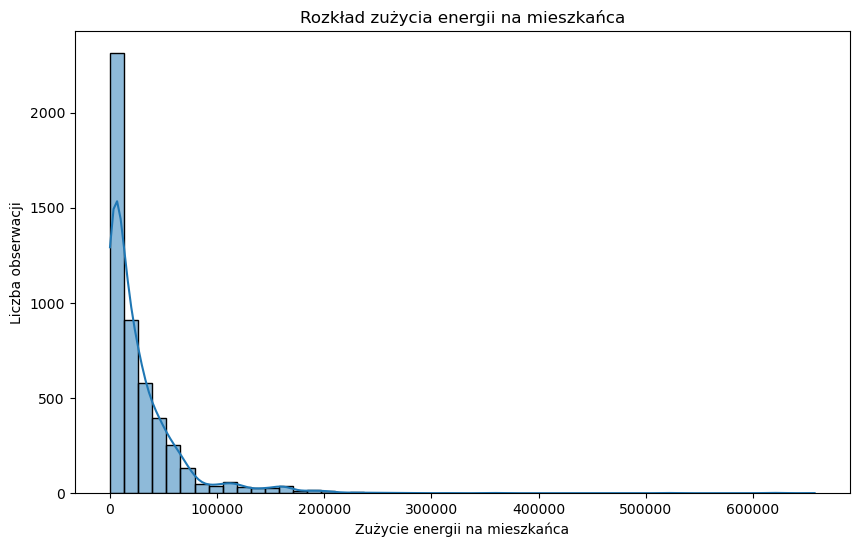

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='energy_per_capita',
    bins=50,
    kde=True
)

plt.title('Rozkład zużycia energii na mieszkańca')
plt.xlabel('Zużycie energii na mieszkańca')
plt.ylabel('Liczba obserwacji')

plt.show()

## Weryfikacja jednostek geograficznych

Przed przeprowadzeniem porównań między krajami zweryfikowano wartości zmiennej `country`. Celem tego etapu jest sprawdzenie, czy po wcześniejszym czyszczeniu w zbiorze pozostały jednostki zagregowane, które mogłyby zaburzyć wyniki dalszej analizy.

In [20]:
# Sprawdzenie liczby jednostek posiadających i nieposiadających kodu ISO

print("Liczba wszystkich jednostek:", df['country'].nunique())

print(
    "Liczba jednostek bez kodu ISO:",
    df.loc[df['iso_code'].isna(), 'country'].nunique()
)

Liczba wszystkich jednostek: 290
Liczba jednostek bez kodu ISO: 71


In [21]:
# Jednostki bez przypisanego kodu ISO

df.loc[
    df['iso_code'].isna(),
    'country'
].drop_duplicates().sort_values().tolist()

['ASEAN (Ember)',
 'Africa (EI)',
 'Africa (Ember)',
 'Africa (Shift)',
 'Asia & Oceania (EIA)',
 'Asia (Ember)',
 'Asia Pacific (EI)',
 'Asia and Oceania (Shift)',
 'Australia and New Zealand (EIA)',
 'CIS (EI)',
 'Central & South America (EIA)',
 'Central America (EI)',
 'Central and South America (Shift)',
 'EU28 (Shift)',
 'Eastern Africa (EI)',
 'Eurasia (EIA)',
 'Eurasia (Shift)',
 'Europe (EI)',
 'Europe (Ember)',
 'Europe (Shift)',
 'European Union (27)',
 'European Union (EIA)',
 'G20 (Ember)',
 'G7 (Ember)',
 'IEO - Africa (EIA)',
 'IEO - Middle East (EIA)',
 'IEO OECD - Europe (EIA)',
 'Kosovo',
 'Latin America and Caribbean (Ember)',
 'Mexico, Chile, and other OECD Americas (EIA)',
 'Middle Africa (EI)',
 'Middle East (EI)',
 'Middle East (EIA)',
 'Middle East (Ember)',
 'Middle East (Shift)',
 'Non-OECD (EI)',
 'Non-OECD (EIA)',
 'Non-OPEC (EI)',
 'Non-OPEC (EIA)',
 'North America (EI)',
 'North America (Ember)',
 'North America (Shift)',
 'OECD (EI)',
 'OECD (EIA)',
 'OEC

## Przygotowanie danych do analizy krajów

W zbiorze zidentyfikowano jednostki zagregowane, takie jak regiony geograficzne i grupy państw. Jednostki te nie posiadają kodu ISO i mogłyby prowadzić do wielokrotnego uwzględnienia tych samych danych w analizach porównawczych.

Dlatego utworzono osobny zbiór zawierający wyłącznie jednostki posiadające kod ISO, który będzie wykorzystywany w dalszych analizach na poziomie krajów.

In [22]:
# Utworzenie zbioru zawierającego jednostki z kodem ISO

df_countries = df[df['iso_code'].notna()].copy()

print("Liczba obserwacji:", df_countries.shape[0])
print("Liczba krajów:", df_countries['country'].nunique())
print("Zakres lat:", df_countries['year'].min(), "-", df_countries['year'].max())

Liczba obserwacji: 4906
Liczba krajów: 219
Zakres lat: 2000 - 2022


## Tworzenie dodatkowej zmiennej analitycznej

Na podstawie danych o PKB i populacji utworzono zmienną PKB na mieszkańca. Umożliwia ona porównywanie poziomu rozwoju gospodarczego krajów niezależnie od wielkości ich populacji oraz późniejszą analizę zależności między poziomem gospodarczym a zużyciem energii.

In [23]:
# PKB na mieszkańca

df_countries['gdp_per_capita'] = (
    df_countries['gdp'] / df_countries['population']
)

df_countries[
    ['country', 'year', 'gdp', 'population', 'gdp_per_capita']
].head()

,country,year,gdp,population,gdp_per_capita
123,Afghanistan,2000,1.128379e+10,19542986.0,577.383256
124,Afghanistan,2001,1.102127e+10,19688634.0,559.778453
125,Afghanistan,2002,1.880487e+10,21000258.0,895.459054
126,Afghanistan,2003,2.107434e+10,22645136.0,930.634461
127,Afghanistan,2004,2.233257e+10,23553554.0,948.161439


## Kraje o największym zużyciu energii

W celu określenia, które państwa odpowiadają za największą część światowego zużycia energii, porównano całkowite zużycie energii pierwotnej w ostatnim dostępnym roku.

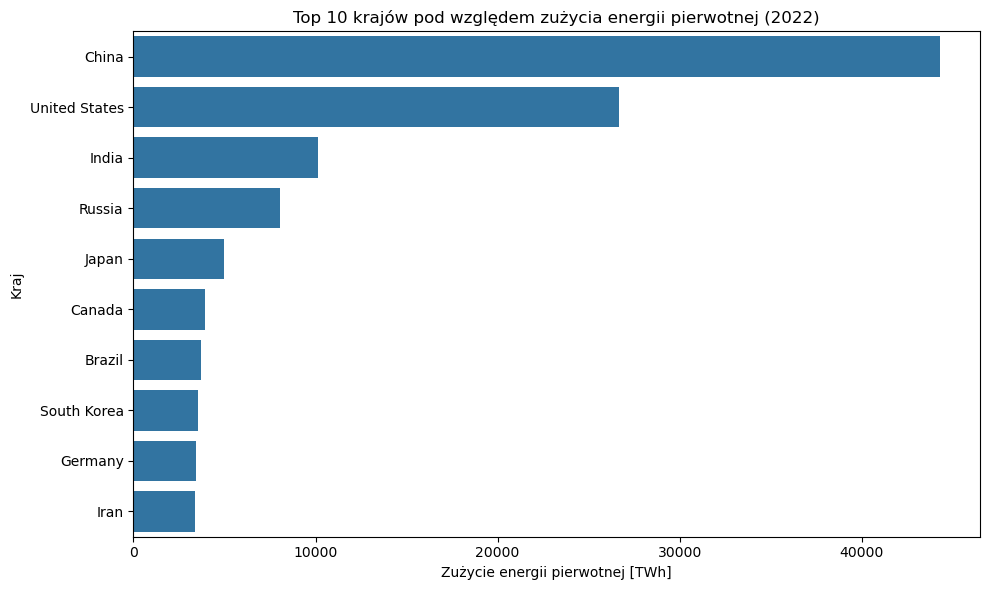

In [24]:
latest_year = df_countries['year'].max()

top10_energy = (
    df_countries[df_countries['year'] == latest_year]
    .nlargest(10, 'primary_energy_consumption')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_energy,
    x='primary_energy_consumption',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem zużycia energii pierwotnej ({latest_year})'
)
plt.xlabel('Zużycie energii pierwotnej [TWh]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

### Wnioski

W 2022 roku największe zużycie energii pierwotnej odnotowano w Chinach, które wyraźnie przewyższały pozostałe analizowane kraje. Drugie miejsce zajmowały Stany Zjednoczone, a kolejne Indie i Rosja. Wyniki wskazują na dużą koncentrację światowego zużycia energii w największych gospodarkach.

## Zużycie energii na mieszkańca

Całkowite zużycie energii jest silnie związane z wielkością kraju i jego populacją. W celu umożliwienia bardziej porównywalnej oceny przeanalizowano zużycie energii na mieszkańca w poszczególnych państwach.

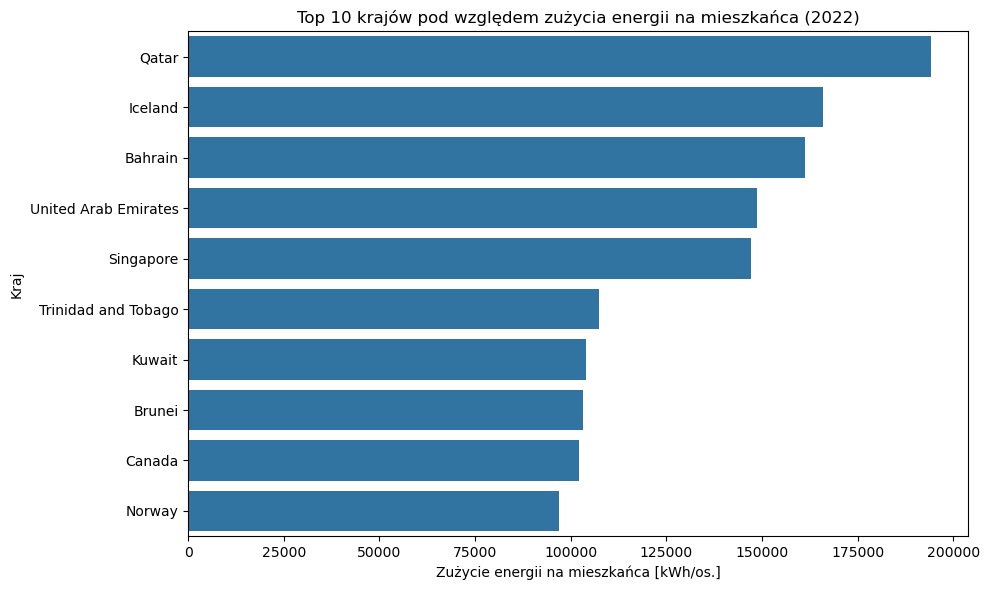

In [26]:
top10_per_capita = (
    df_countries[df_countries['year'] == latest_year]
    .dropna(subset=['energy_per_capita'])
    .nlargest(10, 'energy_per_capita')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_per_capita,
    x='energy_per_capita',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem zużycia energii na mieszkańca ({latest_year})'
)
plt.xlabel('Zużycie energii na mieszkańca [kWh/os.]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

### Wnioski

Ranking zużycia energii na mieszkańca znacząco różni się od rankingu całkowitego zużycia energii. Najwyższe wartości w 2022 roku odnotowano w Katarze, Islandii i Bahrajnie. Pokazuje to, że wielkość populacji ma istotny wpływ na całkowite zużycie energii, dlatego analiza wartości per capita stanowi ważne uzupełnienie porównań między krajami.

## Zmiany zużycia energii w czasie

W celu analizy zmian zachodzących w czasie porównano zużycie energii pierwotnej w wybranych dużych gospodarkach w latach 2000–2022. Pozwala to zaobserwować różnice w kierunku i tempie zmian zapotrzebowania na energię.

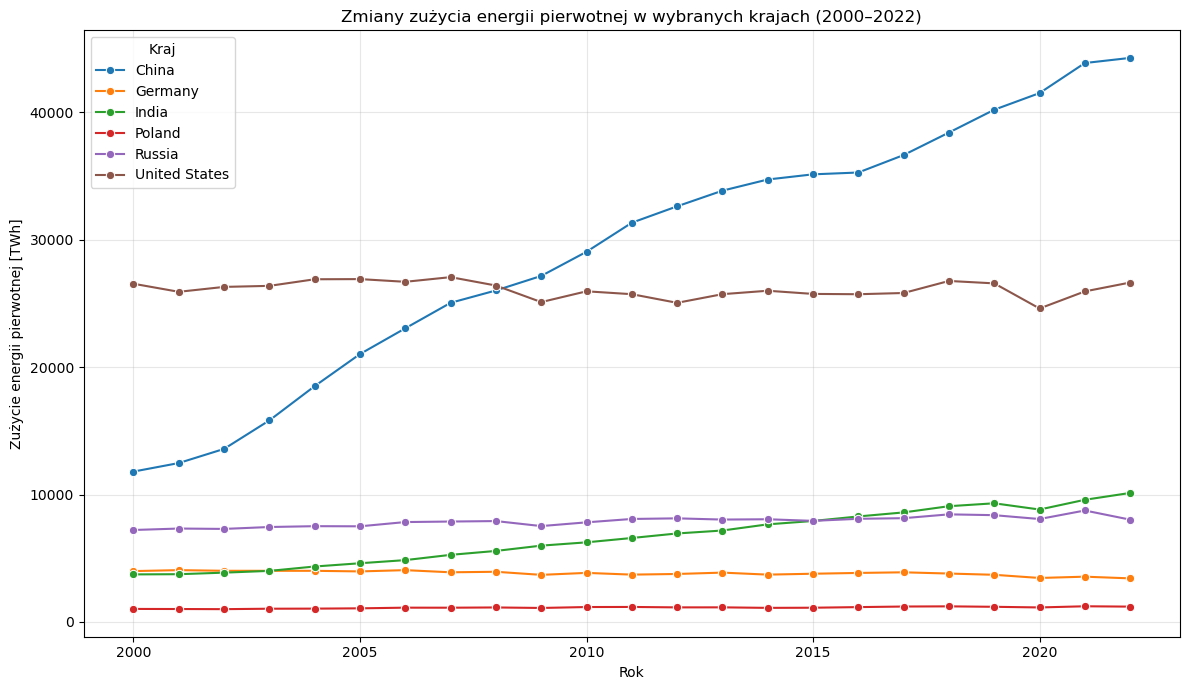

In [27]:
selected_countries = [
    'China',
    'United States',
    'India',
    'Russia',
    'Germany',
    'Poland'
]

energy_trends = df_countries[
    df_countries['country'].isin(selected_countries)
]

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=energy_trends,
    x='year',
    y='primary_energy_consumption',
    hue='country',
    marker='o'
)

plt.title('Zmiany zużycia energii pierwotnej w wybranych krajach (2000–2022)')
plt.xlabel('Rok')
plt.ylabel('Zużycie energii pierwotnej [TWh]')
plt.legend(title='Kraj')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Wnioski

W latach 2000–2022 występowały wyraźne różnice w zmianach zużycia energii pomiędzy analizowanymi krajami. Największy wzrost odnotowały Chiny, które w badanym okresie wyprzedziły Stany Zjednoczone i stały się największym konsumentem energii spośród analizowanych państw. Rosnący trend widoczny jest również w Indiach.

Zużycie energii w Stanach Zjednoczonych pozostawało względnie stabilne, natomiast w Niemczech widoczna jest tendencja spadkowa. Polska charakteryzowała się znacznie niższym i stosunkowo stabilnym poziomem zużycia energii.

## Zależność między PKB a zużyciem energii

Kolejnym etapem analizy jest sprawdzenie zależności pomiędzy poziomem rozwoju gospodarczego a zużyciem energii. W tym celu porównano PKB na mieszkańca ze zużyciem energii na mieszkańca dla danych z 2022 roku.

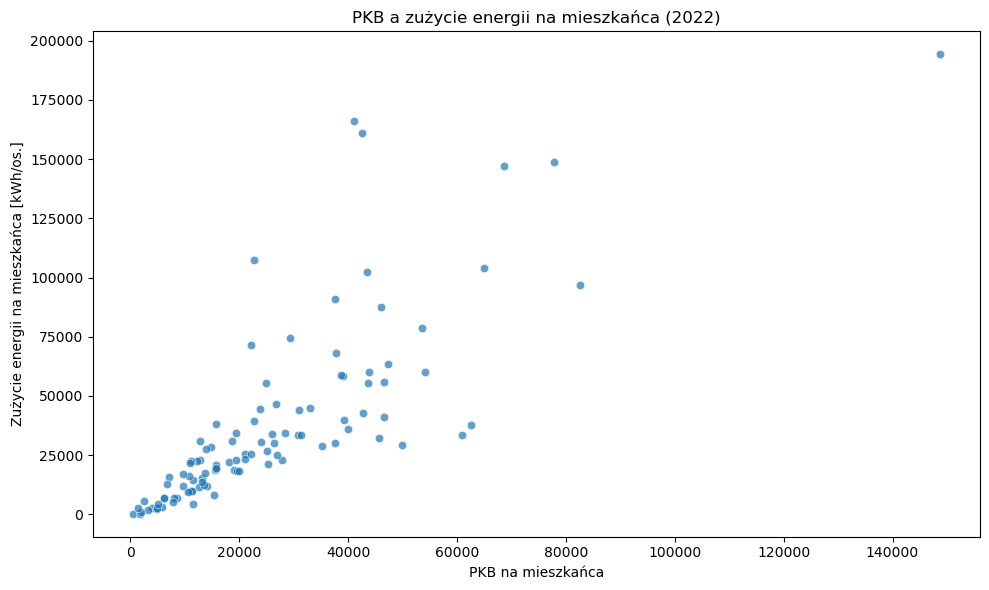

In [28]:
data_2022 = df_countries[
    df_countries['year'] == latest_year
].dropna(subset=['gdp_per_capita', 'energy_per_capita'])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data_2022,
    x='gdp_per_capita',
    y='energy_per_capita',
    alpha=0.7
)

plt.title('PKB a zużycie energii na mieszkańca (2022)')
plt.xlabel('PKB na mieszkańca')
plt.ylabel('Zużycie energii na mieszkańca [kWh/os.]')

plt.tight_layout()
plt.show()

In [29]:
correlation = data_2022[
    ['gdp_per_capita', 'energy_per_capita']
].corr()

correlation

,gdp_per_capita,energy_per_capita
gdp_per_capita,1.000000,0.799576
energy_per_capita,0.799576,1.000000


### Wnioski

Analiza wskazuje na silną dodatnią zależność pomiędzy PKB na mieszkańca a zużyciem energii na mieszkańca. Współczynnik korelacji wynosi około 0,80, co oznacza, że kraje o wyższym PKB na mieszkańca zazwyczaj charakteryzują się również wyższym zużyciem energii na mieszkańca.

Na wykresie widoczne są jednak również obserwacje odstające, dlatego poziom rozwoju gospodarczego nie jest jedynym czynnikiem wpływającym na zużycie energii. Korelacja nie oznacza również związku przyczynowo-skutkowego.

## Produkcja energii elektrycznej ze źródeł niskoemisyjnych

Kolejnym elementem analizy jest porównanie produkcji energii elektrycznej ze źródeł niskoemisyjnych. Do tej kategorii zaliczane są między innymi odnawialne źródła energii oraz energia jądrowa.

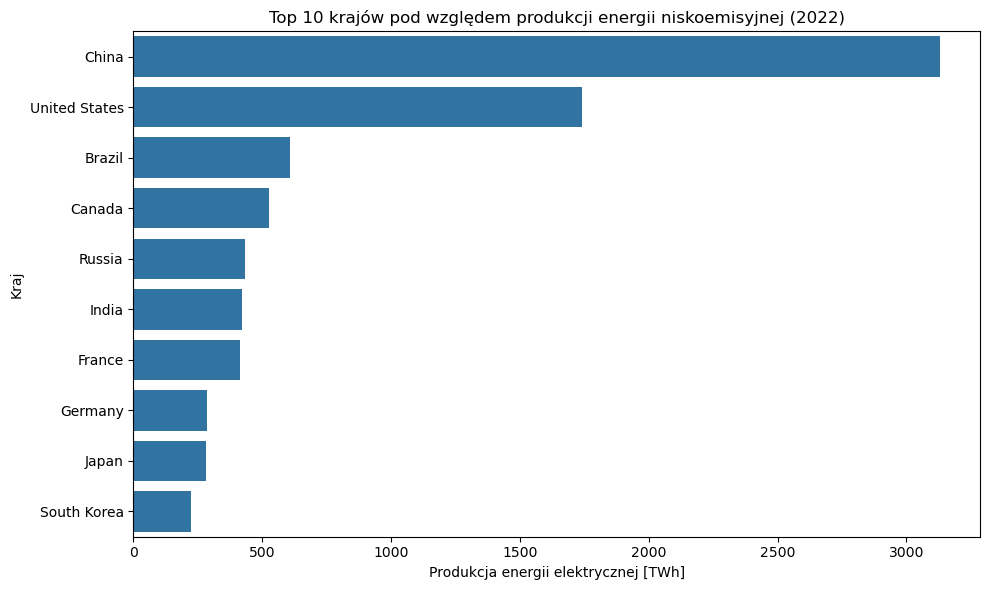

In [30]:
top10_low_carbon = (
    df_countries[df_countries['year'] == latest_year]
    .dropna(subset=['low_carbon_electricity'])
    .nlargest(10, 'low_carbon_electricity')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_low_carbon,
    x='low_carbon_electricity',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem produkcji energii niskoemisyjnej ({latest_year})'
)
plt.xlabel('Produkcja energii elektrycznej [TWh]')
plt.ylabel('Kraj')

plt.tight_layout()
plt.show()

### Wnioski

W 2022 roku największą produkcję energii elektrycznej ze źródeł niskoemisyjnych odnotowano w Chinach, które wyraźnie przewyższały pozostałe analizowane kraje. Drugie miejsce zajmowały Stany Zjednoczone, natomiast kolejne pozycje zajmowały m.in. Brazylia, Kanada, Rosja i Indie.

Ranking przedstawia wartości bezwzględne, dlatego nie określa udziału źródeł niskoemisyjnych w całkowitej produkcji energii elektrycznej danego kraju.

## Produkcja energii hydroelektrycznej

Przeanalizowano również produkcję energii elektrycznej z hydroenergetyki. Porównanie pozwala wskazać kraje, w których produkcja energii z tego źródła osiąga największe wartości.

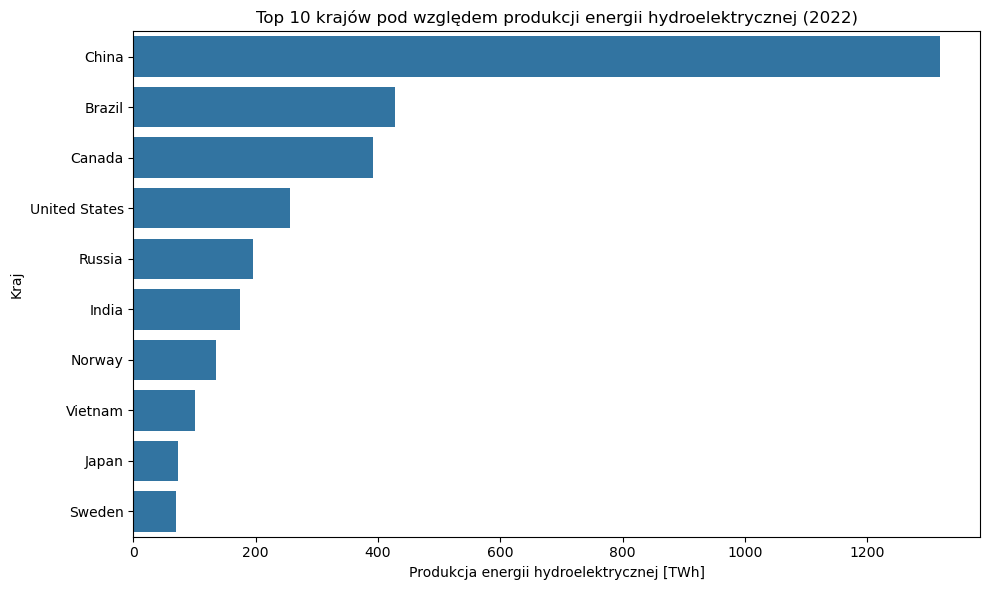

In [ ]:
top10_hydro = (
    df_countries[df_countries['year'] == latest_year]
    .dropna(subset=['hydro_electricity'])
    .nlargest(10, 'hydro_electricity')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10_hydro,
    x='hydro_electricity',
    y='country'
)

plt.title(
    f'Top 10 krajów pod względem produkcji energii hydroelektrycznej ({latest_year})'
)
plt.xlabel('Produkcja energii hydroelektrycznej [TWh]')
plt.ylabel('Kraj')
 
plt.tight_layout()
plt.show()

## Zmiany produkcji energii niskoemisyjnej w czasie

W celu oceny zmian zachodzących w sektorze energetycznym przeanalizowano produkcję energii elektrycznej ze źródeł niskoemisyjnych w wybranych krajach w latach 2000–2022.

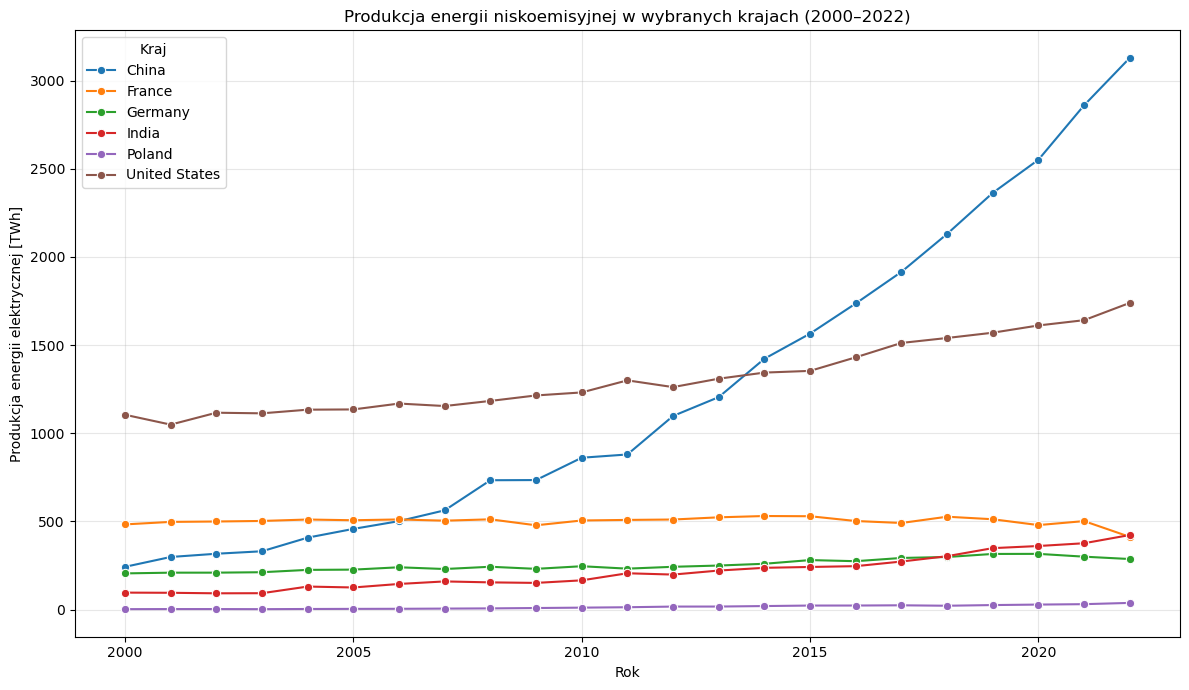

In [33]:
selected_countries = [
    'China',
    'United States',
    'India',
    'Germany',
    'France',
    'Poland'
]

low_carbon_trends = df_countries[
    df_countries['country'].isin(selected_countries)
]

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=low_carbon_trends,
    x='year',
    y='low_carbon_electricity',
    hue='country',
    marker='o'
)

plt.title('Produkcja energii niskoemisyjnej w wybranych krajach (2000–2022)')
plt.xlabel('Rok')
plt.ylabel('Produkcja energii elektrycznej [TWh]')
plt.legend(title='Kraj')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analiza korelacji

W celu zbadania zależności pomiędzy najważniejszymi zmiennymi numerycznymi obliczono macierz korelacji. Analiza pozwala określić kierunek oraz siłę zależności liniowych między zmiennymi.

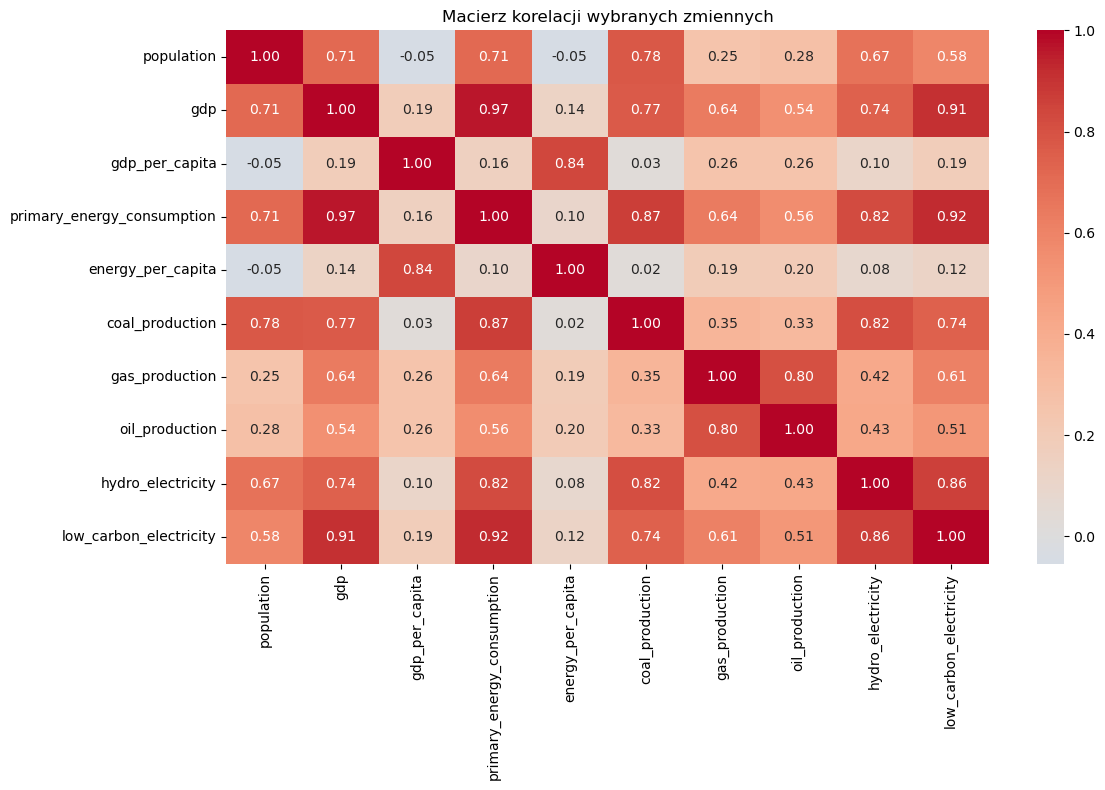

In [34]:
correlation_columns = [
    'population',
    'gdp',
    'gdp_per_capita',
    'primary_energy_consumption',
    'energy_per_capita',
    'coal_production',
    'gas_production',
    'oil_production',
    'hydro_electricity',
    'low_carbon_electricity'
]

corr_matrix = df_countries[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Macierz korelacji wybranych zmiennych')

plt.tight_layout()
plt.show()

## Analiza zużycia energii pierwotnej według kontynentów (TM)

In [ ]:
# wyświetlenie nazw kolumn ze zbioru  (poglądowo)
df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='str', length=129)

In [ ]:
# wyświetlenie unikalnych wartości w kolumnie 'country' (poglądowo)
df.country.unique()

<ArrowStringArray>
[      'ASEAN (Ember)',         'Afghanistan',              'Africa',
         'Africa (EI)',      'Africa (Ember)',      'Africa (Shift)',
             'Albania',             'Algeria',      'American Samoa',
              'Angola',
 ...
   'Wake Island (EIA)', 'Wake Island (Shift)',  'West Germany (EIA)',
 'Western Africa (EI)',      'Western Sahara',               'World',
               'Yemen',          'Yugoslavia',              'Zambia',
            'Zimbabwe']
Length: 306, dtype: str

In [ ]:
# wyświetlenie unikalnych wartości w kolumnie 'country' 
# dla jednostek bez przypisanego kodu ISO (poglądowo) 

df[df.iso_code.isna()].country.unique()

<ArrowStringArray>
[                               'ASEAN (Ember)',
                                       'Africa',
                                  'Africa (EI)',
                               'Africa (Ember)',
                               'Africa (Shift)',
                                         'Asia',
                         'Asia & Oceania (EIA)',
                                 'Asia (Ember)',
                            'Asia Pacific (EI)',
                     'Asia and Oceania (Shift)',
              'Australia and New Zealand (EIA)',
                                     'CIS (EI)',
                'Central & South America (EIA)',
                         'Central America (EI)',
            'Central and South America (Shift)',
                               'Czechoslovakia',
                                 'EU28 (Shift)',
                           'East Germany (EIA)',
                          'Eastern Africa (EI)',
                                'Eurasia (EIA)',
 

Na potrzeby analizy porównawczej wybrano wyłącznie rekordy, których nazwy odpowiadają podstawowym nazwom kontynentów, tj. Afryce, Azji, Europie, Ameryce Północnej, Ameryce Południowej oraz Oceanii. Nie uwzględniono rekordów zawierających dodatkowe oznaczenia w nawiasach, takich jak „Africa (EI)” czy „Africa (Ember)”. Wynika to z faktu, że w zbiorze występują różne agregaty regionalne związane z poszczególnymi źródłami danych i metodami ich opracowania. Ich połączenie z podstawowymi agregatami mogłoby prowadzić do wielokrotnego uwzględnienia podobnych obszarów geograficznych oraz utrudniać jednoznaczną interpretację wyników.

W analizie nie dokonywano również samodzielnego sumowania danych dotyczących poszczególnych państw w celu wyznaczenia wartości dla kontynentów. Wykorzystano gotowe agregaty kontynentalne udostępnione w zbiorze danych. Pozwala to zachować sposób agregacji zastosowany przez autorów źródłowego zbioru oraz uniknąć potencjalnych rozbieżności wynikających z samodzielnego sumowania danych dla państw i regionów.

In [ ]:
# utworzenie zbioru danych do analiz dla kontynentów

continents = [
    'Africa',
    'Asia',
    'Europe',
    'North America',
    'South America',
    'Oceania'
]

df_continents = df[df['country'].isin(continents)]
df_continents = df_continents[df_continents['year'] >= 2000]
df_continents

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
245,Africa,2000,NaN,818952374.0,NaN,NaN,0.000,0.000,0.000,2.686,...,0.000,0.001,786.364,0.460,0.519,0.281,0.230,0.634,0.055,0.016
246,Africa,2001,NaN,839464127.0,NaN,NaN,0.000,0.000,0.000,2.585,...,0.000,0.001,136.798,0.702,1.221,0.548,0.460,1.454,0.105,0.037
247,Africa,2002,NaN,860611762.0,NaN,NaN,0.491,0.570,0.491,2.556,...,0.004,0.001,6.739,0.074,1.295,0.500,0.430,1.504,0.093,0.039
248,Africa,2003,NaN,882349569.0,NaN,10.272,0.050,0.613,0.541,2.244,...,0.004,0.002,20.744,0.259,1.553,0.691,0.610,1.760,0.126,0.044
249,Africa,2004,NaN,904781595.0,NaN,17.630,0.095,0.704,0.637,2.420,...,0.004,0.002,43.443,0.661,2.214,0.862,0.780,2.447,0.151,0.059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18052,South America,2018,NaN,424740741.0,NaN,14.015,33.613,643.812,273.453,138.414,...,0.897,0.378,15.867,20.898,158.480,141.380,60.050,373.122,5.192,2.230
18053,South America,2019,NaN,428318218.0,NaN,9.723,26.589,700.511,300.042,136.184,...,1.326,0.581,21.151,32.812,191.292,167.913,71.920,446.612,6.213,2.730
18054,South America,2020,NaN,431530105.0,NaN,-9.513,-28.544,629.151,271.498,146.085,...,1.850,0.872,9.592,17.579,208.871,182.791,78.880,484.025,6.805,3.215
18055,South America,2021,NaN,434254167.0,NaN,0.015,0.041,625.299,271.539,148.162,...,2.599,1.186,25.652,52.619,261.490,227.217,98.670,602.160,8.044,3.719


In [31]:
# Sprawdzenie brakujących wartości dla analizowanej zmiennej
df_continents[
    df_continents['year'].isin([2000, 2022])
][['country', 'year', 'primary_energy_consumption']].isna().sum()


country                       0
year                          0
primary_energy_consumption    0
dtype: int64

In [33]:
# Sprawdzenie liczby rekordów dla każdego kontynentu i roku
df_continents[
    df_continents['year'].isin([2000, 2022])
].groupby(['country', 'year']).size()


country        year
Africa         2000    1
               2022    1
Asia           2000    1
               2022    1
Europe         2000    1
               2022    1
North America  2000    1
               2022    1
Oceania        2000    1
               2022    1
South America  2000    1
               2022    1
dtype: int64

### Analiza:
Jak zmieniło się zużycie energii pierwotnej ('primary_energy_consumption') na poszczególnych kontynentach pomiędzy 2000 a 2022 rokiem?

In [37]:
# Porównanie zużycia energii pierwotnej w 2000 i 2022 roku

energy_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='primary_energy_consumption'
    )
)
energy_comparison


year,2000,2022
country,,
Africa,3195.780,5626.826
Asia,36846.555,90365.438
Europe,31077.365,28543.871
North America,32465.496,33580.207
Oceania,1534.817,1894.211
South America,5021.526,7340.591


In [38]:
energy_comparison.describe()

year,2000,2022
count,6.000000,6.000000
mean,18356.923167,27891.857333
std,16693.737082,33255.659693
min,1534.817000,1894.211000
25%,3652.216500,6055.267250
50%,18049.445500,17942.231000
75%,32118.463250,32321.123000
max,36846.555000,90365.438000


In [60]:
# Zmiana zużycia energii w wartościach bezwzględnych
energy_comparison['change'] = (
    energy_comparison[2022] - energy_comparison[2000]
)

# Procentowa zmiana zużycia energii
energy_comparison['change_in_%'] = (
    (energy_comparison[2022] - energy_comparison[2000])
    / energy_comparison[2000] * 100
)

# Zaokrąglenie wyników do dwóch miejsc po przecinku
energy_comparison = energy_comparison.round(2)

# Wyświetlenie wyników w kolejności od największej do najmniejszej zmiany procentowej
energy_comparison = energy_comparison.sort_values('change_in_%', ascending=False)

energy_comparison

year,2000,2022,change,change_in_%
country,,,,
Asia,36846.56,90365.44,53518.88,145.25
Africa,3195.78,5626.83,2431.05,76.07
South America,5021.53,7340.59,2319.06,46.18
Oceania,1534.82,1894.21,359.39,23.42
North America,32465.50,33580.21,1114.71,3.43
Europe,31077.36,28543.87,-2533.49,-8.15


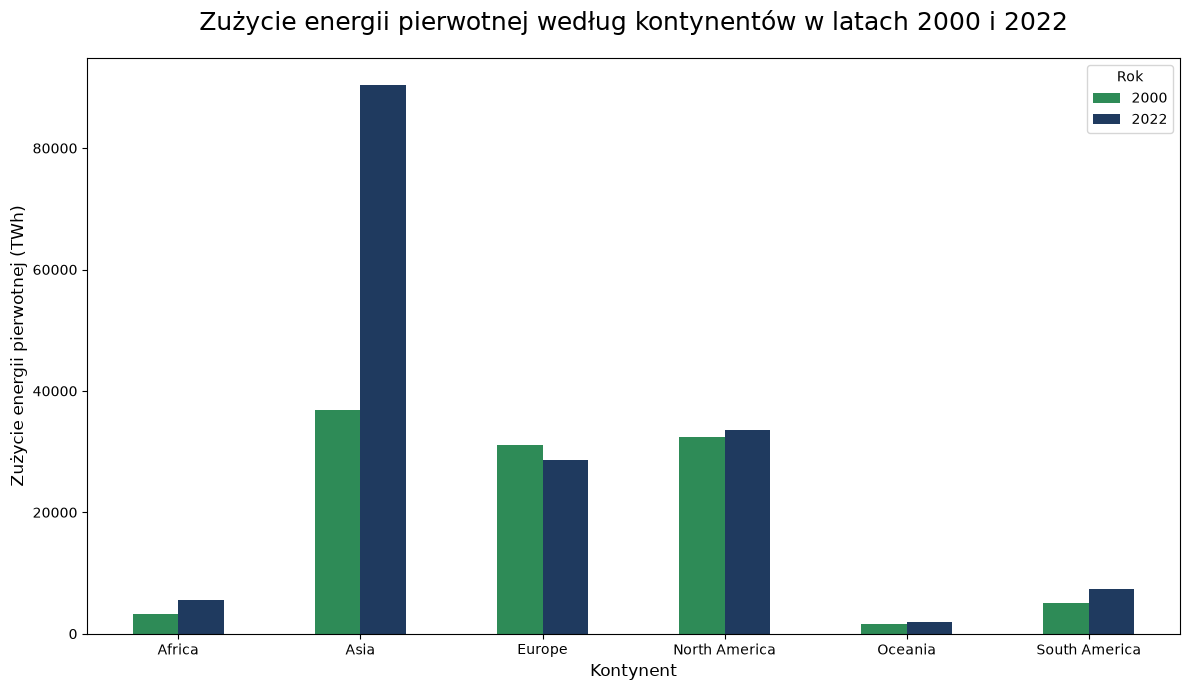

In [44]:
# wykres kolumnowy
# Zużycie energii pierwotnej według kontynentów w latach 2000 i 2022

energy_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Zużycie energii pierwotnej według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Zużycie energii pierwotnej (TWh)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Rok')
plt.tight_layout()
plt.show()

W celu porównania zmian w zużyciu energii pierwotnej zestawiono wartości dla 2000 i 2022 roku. Zastosowanie dwóch punktów czasowych pozwala określić kierunek oraz skalę zmian zachodzących w poszczególnych regionach świata.

Największy procentowy wzrost zużycia energii pierwotnej w analizowanym okresie odnotowano w Azji (145,25%), a najmniejszy w Ameryce Północnej (3,43%). W Europie, jako jedynym kontynencie wśród rozpatrywanych, zanotowano spadek (o 8,15%) zużycia energii pierwotnej w 2022 r. w porównaniu z 2000 r. 

## Analiza produkcji energii elektrycznej w poszczególnych częściach świata (TM)

Do porównania produkcji energii elektrycznej wykorzystano zmienną electricity_generation, która przedstawia całkowitą ilość energii elektrycznej wytworzonej w danym kraju lub regionie, wyrażoną w terawatogodzinach (TWh). 

Analizę przeprowadzono dla sześciu wybranych kontynentów, wykorzystując wartości z 2000 oraz 2022 roku. Takie zestawienie pozwala określić zarówno zmianę poziomu produkcji energii elektrycznej, jak i tempo tej zmiany w poszczególnych częściach świata. Podobnie jak w przypadku analizy zużycia energii pierwotnej, obliczono zmianę w wartościach bezwzględnych oraz procentową pomiędzy analizowanymi latami.

In [46]:
# Wyświetlenie wszystkich nazw kolumn
print(df_continents.columns.tolist())


['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consumption', 'gas_elec_per_capita', '

In [55]:
# Sprawdzenie brakujących wartości produkcji energii elektrycznej
df_continents[
    df_continents['year'].isin([2000, 2022])
][['country', 'year', 'electricity_generation']].isna().sum()


country                   0
year                      0
electricity_generation    0
dtype: int64

In [56]:
# Sprawdzenie liczby rekordów dla każdego kontynentu i roku

df_continents[
    df_continents['year'].isin([2000, 2022])
].groupby(['country', 'year']).size()


country        year
Africa         2000    1
               2022    1
Asia           2000    1
               2022    1
Europe         2000    1
               2022    1
North America  2000    1
               2022    1
Oceania        2000    1
               2022    1
South America  2000    1
               2022    1
dtype: int64

### Analiza:


In [ ]:
# Porównanie produkcji energii elektrycznej w 2000 i 2022 roku

electricity_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='electricity_generation'
    )
)

# Zmiana produkcji energii elektrycznej
electricity_comparison['change'] = (
    electricity_comparison[2022]
    - electricity_comparison[2000]
)

# Procentowa zmiana produkcji energii elektrycznej
electricity_comparison['change_in_%'] = (
    (electricity_comparison[2022] - electricity_comparison[2000])
    / electricity_comparison[2000]
    * 100
)

# Zaokrąglenie wyników
electricity_comparison = electricity_comparison.round(2)

# Wyświetlenie wyników w kolejności od największej do najmniejszej zmiany procentowej
electricity_comparison = electricity_comparison.sort_values('change_in_%', ascending=False)

electricity_comparison


year,2000,2022,change,change_in_%
country,,,,
Asia,4637.52,16214.56,11577.04,249.64
Africa,420.55,892.73,472.18,112.28
South America,689.00,1256.98,567.98,82.44
Oceania,243.35,318.24,74.89,30.78
North America,4676.00,5638.28,962.28,20.58
Europe,4305.37,4781.19,475.82,11.05


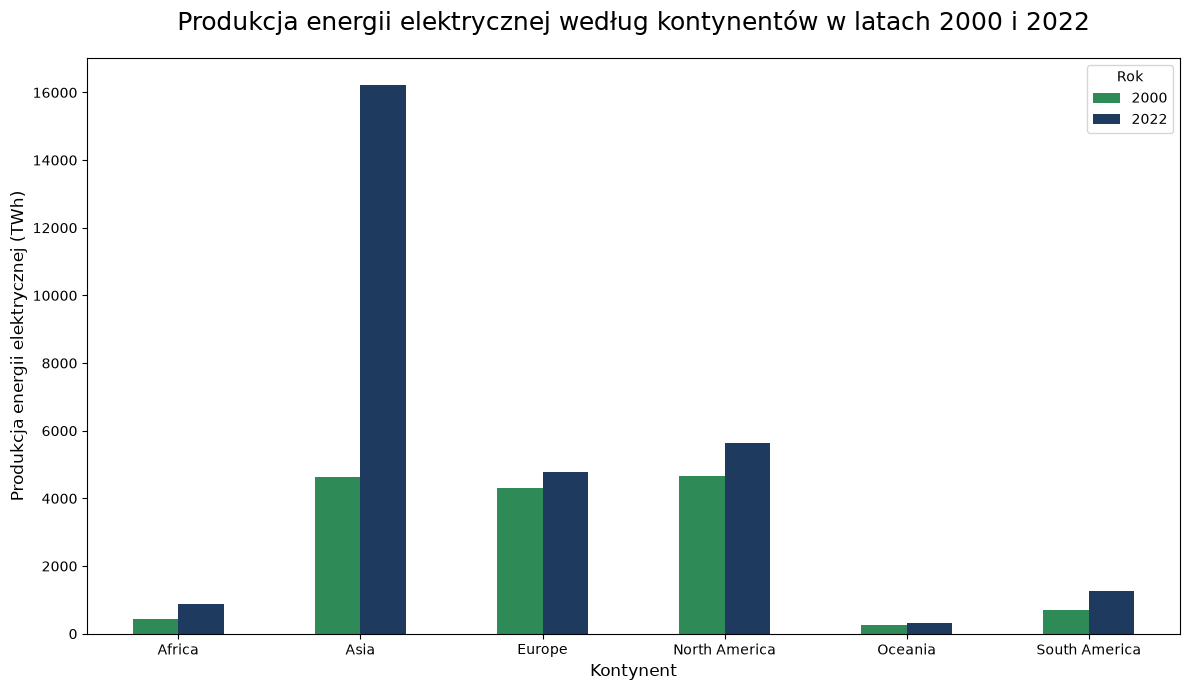

In [50]:
# Wykres: Produkcja energii elektrycznej według kontynentów – 2000 i 2022

electricity_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Produkcja energii elektrycznej według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Produkcja energii elektrycznej (TWh)', fontsize=12)

plt.xticks(rotation=0)
plt.legend(title='Rok')

plt.tight_layout()
plt.show()


Analiza produkcji energii elektrycznej wskazuje na zróżnicowanie jej poziomu pomiędzy poszczególnymi kontynentami. W 2022 roku największą produkcją charakteryzowała się Azja, natomiast najmniejszą wartość odnotowano dla Oceanii. W porównaniu z 2000 rokiem produkcja energii elektrycznej wzrosła na wszystkich analizowanych kontynentach.

Największy wzrost produkcji w ujęciu procentowym odnotowano w Azji (249.64%), a następnie w Afryce (112.28%) i Ameryce Południowej (82.44%). Najmniejszy wzrost odnotowano w Europie (11.05%).


## Znaczenie odnawialnych źródeł energii (TM)
### - udział OZE w zużyciu energii na poszczególnych kontynentach

In [51]:
# Sprawdzenie brakujących wartości udziału OZE w 2000 i 2022 roku

df_continents[
    df_continents['year'].isin([2000, 2022])
][['country', 'year', 'renewables_share_energy']].isna().sum()


country                    0
year                       0
renewables_share_energy    0
dtype: int64

In [ ]:
# Porównanie udziału OZE w zużyciu energii w 2000 i 2022 roku

renewables_share_comparison = (
    df_continents[
        df_continents['year'].isin([2000, 2022])
    ]
    .pivot(
        index='country',
        columns='year',
        values='renewables_share_energy'
    )
)

# Zmiana udziału OZE w punktach procentowych
renewables_share_comparison['change_pp'] = (
    renewables_share_comparison[2022]
    - renewables_share_comparison[2000]
)

# Zaokrąglenie wyników
renewables_share_comparison = renewables_share_comparison.round(2)

# Wyświetlenie wyników w kolejności od największej do najmniejszej zmiany p.proc.
renewables_share_comparison = renewables_share_comparison.sort_values('change_pp', ascending=False)

renewables_share_comparison

year,2000,2022,change_pp
country,,,
Oceania,8.83,17.98,9.14
Europe,7.80,16.56,8.76
Asia,4.90,12.04,7.14
North America,7.06,13.28,6.22
South America,33.57,37.78,4.21
Africa,7.21,9.66,2.45


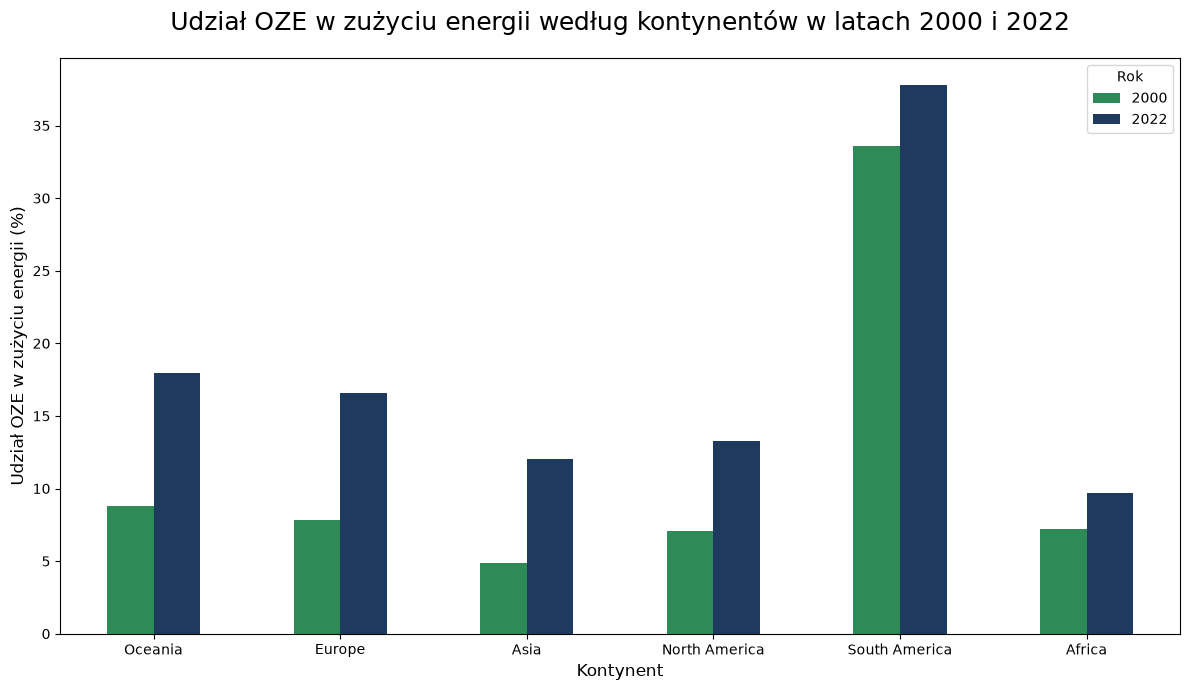

In [ ]:
# Wykres: Udział OZE w zużyciu energii według kontynentów – 2000 i 2022

renewables_share_comparison[[2000, 2022]].plot(
    kind='bar',
    figsize=(12, 7),
    color=['#2E8B57', '#1F3A5F']
)

plt.title(
    'Udział OZE w zużyciu energii według kontynentów w latach 2000 i 2022',
    fontsize=18,
    pad=20
)

plt.xlabel('Kontynent', fontsize=12)
plt.ylabel('Udział OZE w zużyciu energii (%)', fontsize=12)

plt.xticks(rotation=0)
plt.legend(title='Rok')

plt.tight_layout()
plt.show()

W 2022 r. w porównaniu do 2000 r. udział OZE w zużyciu energii wzrósł na wszystkich analizowanych kontynentach. Największy wzrost nastąpił w Oceanii – z poziomu 8,83% do 17,98%. Wysoki wzrost wystąpił również w Europie i Azji. Największy udział OZE w obu analizowanych latach miała Ameryka Południowa, natomiast w 2022 roku najniższy udział odnotowano w Afryce.

## Struktura odnawialnych źródeł energii na poszczególnych kontynentach (TM)

In [63]:
# Sprawdzenie brakujących wartości dla źródeł OZE w 2022 roku

renewable_sources = [
    'hydro_consumption',
    'wind_consumption',
    'solar_consumption',
    'biofuel_consumption',
    'other_renewable_consumption'
]

df_continents[
    df_continents['year'] == 2022
][['country'] + renewable_sources].isna().sum()


country                        0
hydro_consumption              0
wind_consumption               0
solar_consumption              0
biofuel_consumption            0
other_renewable_consumption    0
dtype: int64

In [64]:
# Dane dotyczące zużycia poszczególnych źródeł OZE w 2022 roku

renewable_2022 = (
    df_continents[
        df_continents['year'] == 2022
    ]
    .set_index('country')[renewable_sources]
)

renewable_2022


,hydro_consumption,wind_consumption,solar_consumption,biofuel_consumption,other_renewable_consumption
country,,,,,
Africa,408.593,62.294,47.402,1.122,23.925
Asia,5207.568,2365.340,1944.585,219.470,1142.141
Europe,1819.005,1365.527,607.998,239.864,693.408
North America,1811.065,1301.692,608.449,463.559,273.241
Oceania,113.116,89.993,101.990,1.394,33.991
South America,1858.034,293.241,130.086,273.246,218.916


## Analiza:
Jakie znaczenie mają OZE w całkowitym zużyciu energii na poszczególnych kontynentach w 2022 roku?

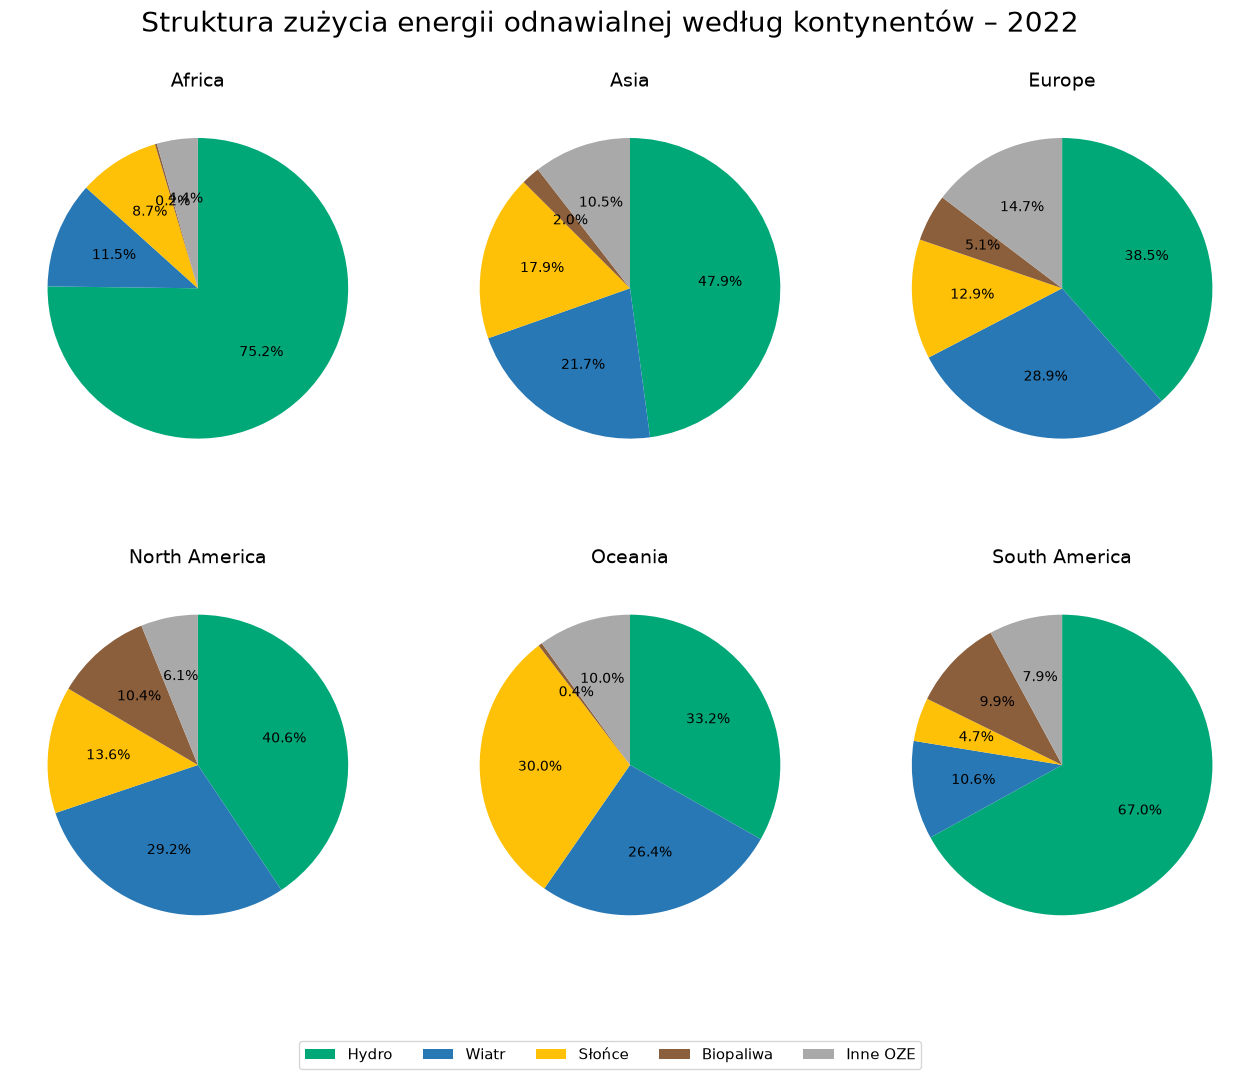

In [70]:
# Wykresy
# Struktura zużycia energii odnawialnej według kontynentów w 2022 roku

fig, axes = plt.subplots(2, 3, figsize=(16, 11))

labels = [
    'Hydro',
    'Wiatr',
    'Słońce',
    'Biopaliwa',
    'Inne OZE'
]

colors = [
    '#00A878',  # Hydro – intensywna zieleń
    '#2878B5',  # Wiatr – niebieski
    '#FFC107',  # Słońce – żółty
    '#8B5E3C',  # Biopaliwa – brązowy
    '#A9A9A9'   # Inne OZE – szary
]

for ax, continent in zip(axes.flat, renewable_2022.index):

    values = renewable_2022.loc[continent]

    ax.pie(
        values,
        labels=None,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        textprops={'fontsize': 10}
)

    ax.set_title(
        continent,
        fontsize=14,
        pad=10
    )

# Wspólny tytuł
fig.suptitle(
    'Struktura zużycia energii odnawialnej według kontynentów – 2022',
    fontsize=20,
    y=0.98
)

# Wspólna legenda
fig.legend(
    labels,
    loc='lower center',
    ncol=5,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.01)
)

plt.subplots_adjust(
    top=0.90,
    bottom=0.12,
    hspace=0.25,
    wspace=0.15
)

plt.show()


In [66]:
# Sprawdzenie zgodności sumy poszczególnych źródeł OZE z całkowitym zużyciem OZE

renewable_check = renewable_2022.sum(axis=1).to_frame('sources_sum')

renewable_check['renewables_consumption'] = (
    df_continents[
        df_continents['year'] == 2022
    ]
    .set_index('country')['renewables_consumption']
)

renewable_check['difference'] = (
    renewable_check['sources_sum']
    - renewable_check['renewables_consumption']
)

renewable_check.round(2)


,sources_sum,renewables_consumption,difference
country,,,
Africa,543.34,543.34,0.0
Asia,10879.10,10879.10,0.0
Europe,4725.80,4725.80,0.0
North America,4458.01,4458.01,-0.0
Oceania,340.48,340.48,0.0
South America,2773.52,2773.52,0.0


W 2022 r. struktura zużycia energii odnawialnej była zróżnicowana w zależności od kontynentu. Na większości kontynentów dominowała energia wodna, szczególnie w Afryce i Ameryce Południowej. Europa i Ameryka Północna charakteryzowały się większym znaczeniem energii wiatrowej, natomiast Oceania wyróżniała się wysokim udziałem energii słonecznej. Najbardziej zróżnicowaną strukturę OZE odnotowano w Azji, gdzie kilka źródeł miało znaczący udział w produkcji energii elektrycznej.


## 1. Analiza udziału odnawialnych źródeł energii (OZE) w czasie


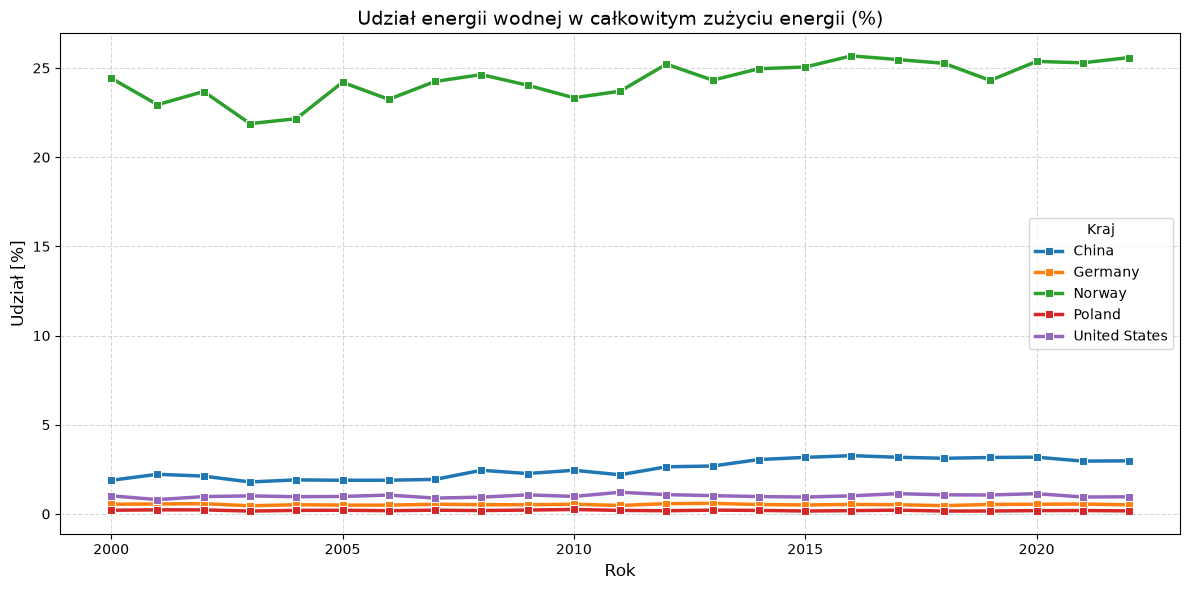

In [ ]:

countries_oze = ['Poland', 'Germany', 'Norway', 'China', 'United States']

df_oze = df_countries[df_countries['country'].isin(countries_oze)].copy()

df_oze['renewables_share_calculated'] = (
    df_oze['hydro_electricity'] / df_oze['primary_energy_consumption']
) * 100

# 3. Wykres
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_oze,
    x='year',
    y='renewables_share_calculated',
    hue='country',
    marker='s',
    linewidth=2.5
)

plt.title('Udział energii wodnej w całkowitym zużyciu energii (%)', fontsize=14)
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Udział [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Kraj')
plt.tight_layout()
plt.show()

## 2. Dynamika zmian zużycia energii rok do roku (%)


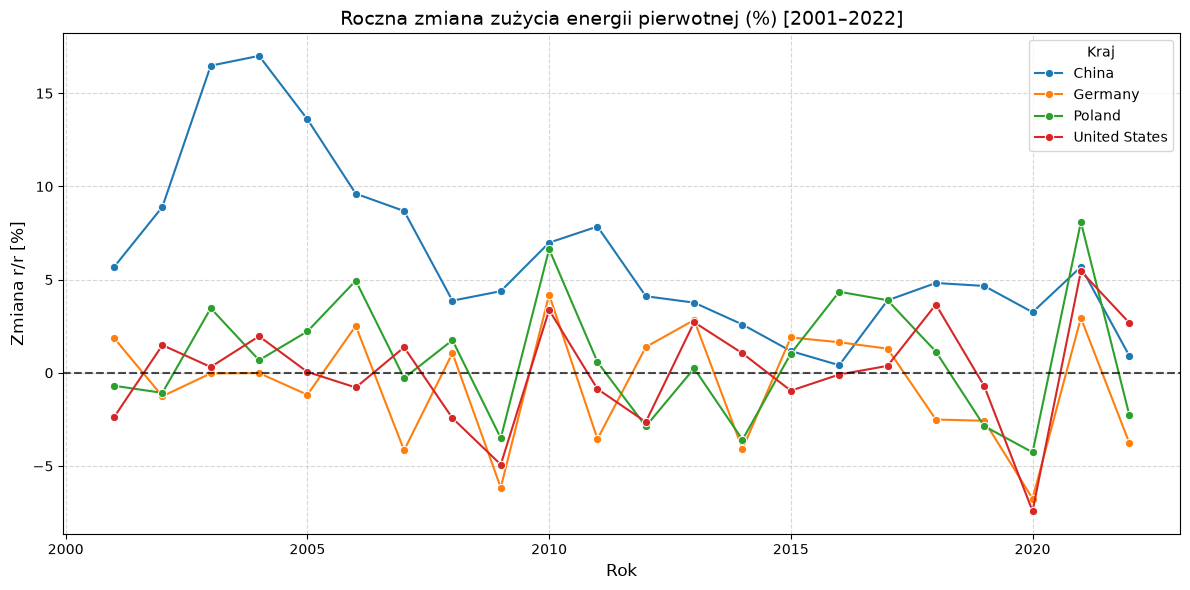

In [ ]:

countries_growth = ['Poland', 'Germany', 'China', 'United States']

df_growth = df_countries[df_countries['country'].isin(countries_growth)].copy()

df_growth = df_growth.sort_values(['country', 'year'])
df_growth['energy_growth_pct'] = df_growth.groupby('country')['primary_energy_consumption'].pct_change() * 100

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_growth,
    x='year',
    y='energy_growth_pct',
    hue='country',
    marker='o'
)

plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Roczna zmiana zużycia energii pierwotnej (%) [2001–2022]', fontsize=14)
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Zmiana r/r [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Kraj')
plt.tight_layout()
plt.show()

 ## 3. Nieliniowa analiza zmian strukturalnych w czasie (Korelacje 2000–2010 vs 2011–2022)


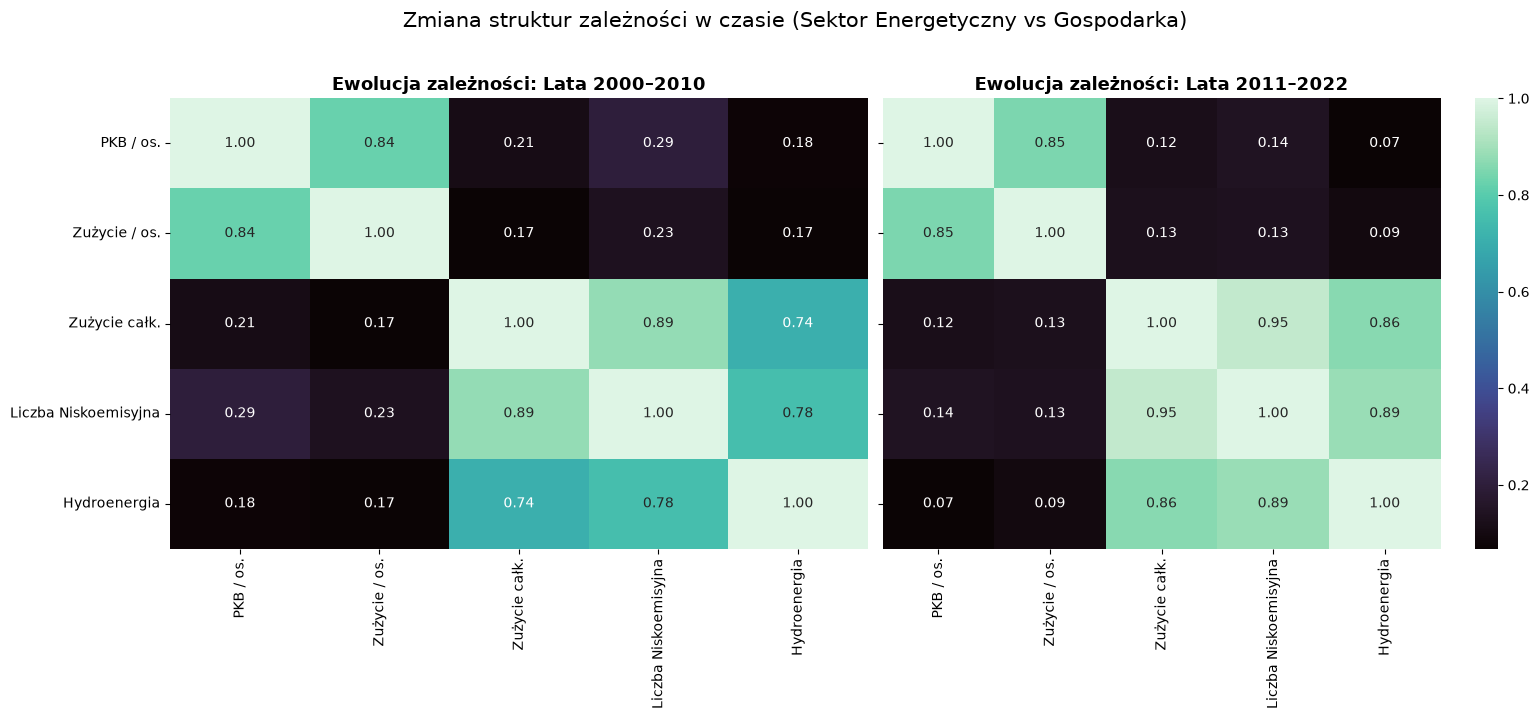

In [ ]:

corr_vars = [
    'gdp_per_capita',
    'energy_per_capita',
    'primary_energy_consumption',
    'low_carbon_electricity',
    'hydro_electricity'
]

df_corr_analysis = df_countries.dropna(subset=corr_vars).copy()

df_period1 = df_corr_analysis[df_corr_analysis['year'] <= 2010][corr_vars].corr()
df_period2 = df_corr_analysis[df_corr_analysis['year'] > 2010][corr_vars].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

labels = ['PKB / os.', 'Zużycie / os.', 'Zużycie całk.', 'Liczba Niskoemisyjna', 'Hydroenergia']

sns.heatmap(
    df_period1, 
    annot=True, 
    fmt='.2f', 
    cmap='mako', 
    cbar=False, 
    ax=axes[0],
    xticklabels=labels,
    yticklabels=labels
)
axes[0].set_title('Ewolucja zależności: Lata 2000–2010', fontsize=13, fontweight='bold')

sns.heatmap(
    df_period2, 
    annot=True, 
    fmt='.2f', 
    cmap='mako', 
    cbar=True, 
    ax=axes[1],
    xticklabels=labels,
    yticklabels=labels
)
axes[1].set_title('Ewolucja zależności: Lata 2011–2022', fontsize=13, fontweight='bold')

plt.suptitle('Zmiana struktur zależności w czasie', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

